<a href="https://colab.research.google.com/github/SahanaDil/Projects/blob/main/000hungarianChickenpox-Analysis%20and%20Forecasting-SARIMA-Approach/SpatioTemporal_Analysis_And_Forecasting_of_Chickenpox_Cases_in_Hungary_(2005_2015)_A_SARIMA_Approach.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spatiotemporal Analysis and Time Series Prediction of Hungarian Chickenpox Cases (2005-2015)*italicized text*


This comprehensive analysis examines weekly varicella case reports from Hungary's 20 counties over a decade, revealing critical epidemiological patterns and data characteristics that inform predictive modeling approaches. The dataset's unique combination of temporal regularity and spatial connectivity makes it particularly valuable for advanced machine learning applications.

A SARIMA (Seasonal Autoregressive Integrated Moving Average) model consists of three main components:

Autoregressive (AR) component: This models the relationship between an observation and a certain number of lagged observations12.

Integrated (I) component: This represents the differencing of observations to make the time series stationary13.

Moving Average (MA) component: This models the relationship between an observation and a residual error from a moving average model applied to lagged observations

Data set : https://archive.ics.uci.edu/dataset/580/hungarian+chickenpox+cases

In [251]:
from datetime import date

today = date.today()
print(f"Today's date is {today}. its me Sahana.D !")

Today's date is 2025-02-27. its me Sahana.D !


In [252]:
from google.colab import drive

# This will prompt you to authorize access
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [253]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima
import joblib

In [254]:
# Dataset initialization

#df=pd.read_csv("/content/drive/MyDrive/HungarianChickPox/hungary_chickenpox.csv")

cases_df = pd.read_csv('/content/drive/MyDrive/HungarianChickPox/hungary_chickenpox.csv', parse_dates=['Date'])

adjacency_df = pd.read_csv('/content/drive/MyDrive/HungarianChickPox/hungary_county_edges.csv')

cases_df_bk = cases_df.copy()

cases_df_bk['Date'] = pd.to_datetime(cases_df_bk['Date'], format='%d/%m/%Y')
#set date as index
cases_df_bk= cases_df_bk.set_index('Date')


cases_df_bk = cases_df_bk.asfreq('W-MON')
cases_df_bk = cases_df_bk.fillna(method='ffill')

print("Missing values:", cases_df_bk.isnull().sum().sum())

cases_df_bk['Total_Cases'] = cases_df_bk.sum(axis=1) #total cases per week

Missing values: 0


In [255]:
# Initial inspection
print(f"Data shape: {cases_df_bk.shape}")
print(f"Counties: {len(cases_df_bk.columns) - 1}")  # Subtract Date column
print(f"Adjacency data shape: {adjacency_df.shape}")
#"print(f"Time range: {cases_df_bk['Date'].min()} to {cases_df_bk['Date'].max()}")

# Display first few rows of each dataset
print("\nFirst 5 rows of cases data:")
print(cases_df_bk.head())

print("\nFirst 5 rows of adjacency data:")
print(adjacency_df.head())

Data shape: (522, 21)
Counties: 20
Adjacency data shape: (102, 4)

First 5 rows of cases data:
            BUDAPEST  BARANYA  BACS  BEKES  BORSOD  CSONGRAD  FEJER  GYOR  \
Date                                                                        
2005-01-03       168       79    30    173     169        42    136   120   
2005-01-10       157       60    30     92     200        53     51    70   
2005-01-17        96       44    31     86      93        30     93    84   
2005-01-24       163       49    43    126      46        39     52   114   
2005-01-31       122       78    53     87     103        34     95   131   

            HAJDU  HEVES  ...  KOMAROM  NOGRAD  PEST  SOMOGY  SZABOLCS  TOLNA  \
Date                      ...                                                   
2005-01-03    162     36  ...       57       2   178      66        64     11   
2005-01-10     84     28  ...       50      29   141      48        29     58   
2005-01-17    191     51  ...       46   

In [256]:
print(cases_df_bk.columns)

Index(['BUDAPEST', 'BARANYA', 'BACS', 'BEKES', 'BORSOD', 'CSONGRAD', 'FEJER',
       'GYOR', 'HAJDU', 'HEVES', 'JASZ', 'KOMAROM', 'NOGRAD', 'PEST', 'SOMOGY',
       'SZABOLCS', 'TOLNA', 'VAS', 'VESZPREM', 'ZALA', 'Total_Cases'],
      dtype='object')


In [257]:


# Check for zero values (potential data issues)
zero_counts = (cases_df_bk == 0).sum()
zero_percentage = (cases_df_bk == 0).mean() * 100
print("\nZero counts per county:")
print(zero_counts)
print("\nZero percentage per county:")
print(zero_percentage.round(2))




# Create adjacency matrix manually
counties = cases_df_bk.columns.tolist()
adjacency_matrix = pd.DataFrame(0, index=counties, columns=counties)

for _, row in adjacency_df.iterrows():
    county1 = row['name_1']
    county2 = row['name_2']
    adjacency_matrix.loc[county1, county2] = 1
    adjacency_matrix.loc[county2, county1] = 1  # Make symmetric

print("\nAdjacency matrix (first 5x5):")
print(adjacency_matrix.iloc[:5, :5])



Zero counts per county:
BUDAPEST        1
BARANYA        19
BACS           28
BEKES          28
BORSOD          3
CSONGRAD       33
FEJER          22
GYOR           11
HAJDU          15
HEVES          23
JASZ            9
KOMAROM        28
NOGRAD         36
PEST            1
SOMOGY         21
SZABOLCS       19
TOLNA          51
VAS            44
VESZPREM       14
ZALA           45
Total_Cases     0
dtype: int64

Zero percentage per county:
BUDAPEST       0.19
BARANYA        3.64
BACS           5.36
BEKES          5.36
BORSOD         0.57
CSONGRAD       6.32
FEJER          4.21
GYOR           2.11
HAJDU          2.87
HEVES          4.41
JASZ           1.72
KOMAROM        5.36
NOGRAD         6.90
PEST           0.19
SOMOGY         4.02
SZABOLCS       3.64
TOLNA          9.77
VAS            8.43
VESZPREM       2.68
ZALA           8.62
Total_Cases    0.00
dtype: float64

Adjacency matrix (first 5x5):
          BUDAPEST  BARANYA  BACS  BEKES  BORSOD
BUDAPEST         1        0     0      0

In [258]:
# Basic statistics
print("\nSummary statistics:")
print(cases_df_bk.describe().T)


Summary statistics:
             count        mean         std   min     25%    50%      75%  \
BUDAPEST     522.0  101.245211   76.354872   0.0   34.25   93.0   149.00   
BARANYA      522.0   34.204981   32.567222   0.0    8.00   25.0    51.00   
BACS         522.0   37.166667   36.843095   0.0    8.00   29.5    53.00   
BEKES        522.0   28.911877   37.618092   0.0    4.00   14.0    38.75   
BORSOD       522.0   57.082375   50.725437   0.0   14.25   46.5    83.75   
CSONGRAD     522.0   31.488506   33.790208   0.0    6.00   20.5    47.00   
FEJER        522.0   33.272031   31.397989   0.0    7.00   24.0    51.75   
GYOR         522.0   41.436782   36.014297   0.0    9.00   35.0    63.00   
HAJDU        522.0   47.097701   44.610836   0.0   11.00   37.0    68.00   
HEVES        522.0   29.691571   31.857750   0.0    6.25   21.0    41.00   
JASZ         522.0   40.869732   37.283299   0.0   10.00   31.0    61.75   
KOMAROM      522.0   25.643678   24.467995   0.0    6.00   19.0    

observation:

Budapest and Pest have the highest average weekly cases (101.25 and 86.1).
Max weekly cases ranges from 479 to 112 ( Minimum is zero for all the counties)


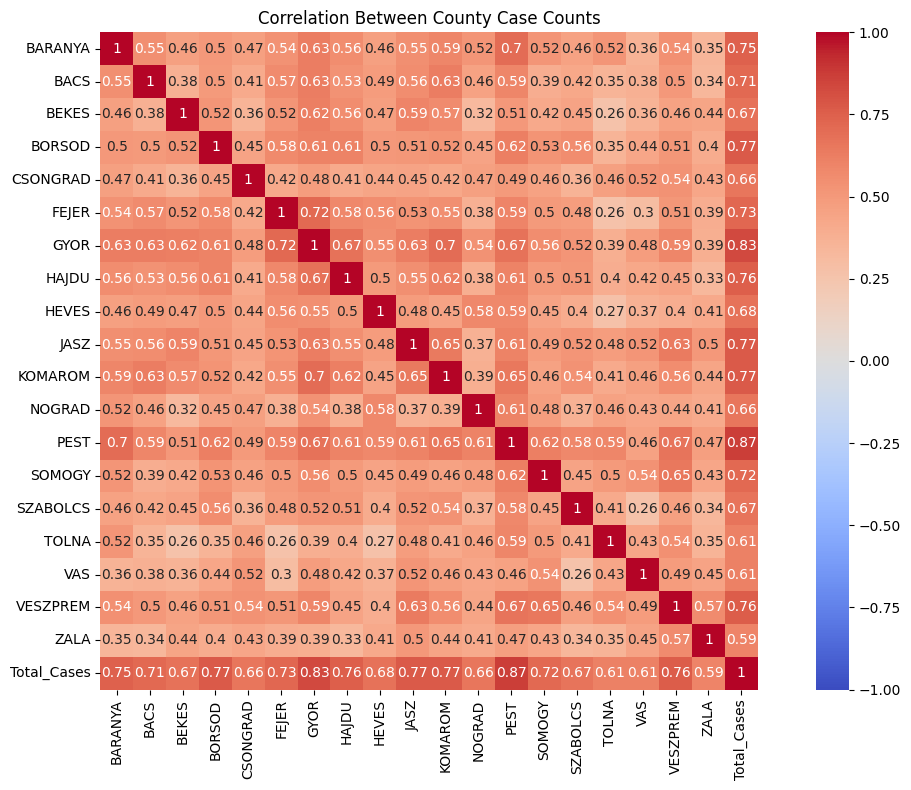

In [259]:
# Calculate correlation matrix
#exclude date column
#cases_df_bk = cases_df_bk.copy()
correlation_matrix = cases_df_bk.iloc[:, 1:21].corr()

#plt.figure(figsize=(14, 12))
plt.figure(figsize=(12, 8))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True)
plt.title('Correlation Between County Case Counts')
plt.tight_layout()
plt.show()

observation:
1.No Negative Correlations
2.Pest county shows strong correlation with many counties (esp Baranya at 0.7)
3.Gyor and Fejer have strong correlation(0.72)
4.Most exhibit moderate to strong positive correlations with each other

In [260]:
#!pip install statsmodels
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [261]:
#Prepare Data for Modeling
cases_df2 = cases_df_bk[['Total_Cases']].copy()
# Split data into training and testing sets
train_size = int(len(cases_df2) * 0.70)
train = cases_df2.iloc[:train_size].copy()
test = cases_df2.iloc[train_size:].copy()

# Data Scaling
f_transformer = RobustScaler()

# Scale the data
train['Total_Cases_scaled'] = f_transformer.fit_transform(train[['Total_Cases']])
test['Total_Cases_scaled'] = f_transformer.transform(test[['Total_Cases']])

# 4. Model Training
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 52)

model = SARIMAX(train['Total_Cases_scaled'],
                order=order,
                seasonal_order=seasonal_order,
                freq='W-MON',
                enforce_stationarity=False,
                enforce_invertibility=False)
results = model.fit(disp=False) # Suppress convergence output

In [262]:
#Model Training
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 52)

model = SARIMAX(train['Total_Cases_scaled'],
                order=order,
                seasonal_order=seasonal_order,
                freq='W-MON',
                enforce_stationarity=False,
                enforce_invertibility=False)
results = model.fit(disp=False) # Suppress convergence output

In [263]:
#  Prediction

train_pred = results.get_prediction(start=train.index[0], dynamic=False)
test_pred = results.get_forecast(steps=len(test))

# Inverse transform the predictions
train['Predicted'] = f_transformer.inverse_transform(
    train_pred.predicted_mean.values.reshape(-1, 1)
)
test['Predicted'] = f_transformer.inverse_transform(
    test_pred.predicted_mean.values.reshape(-1, 1)
)

Train Metrics: {'MAE': 170.53859038211797, 'RMSE': 247.6599427341878, 'MAPE': 26.1128396274175}
Test Metrics: {'MAE': 201.44897800575734, 'RMSE': 279.62080632348034, 'MAPE': 68.87683620490476}


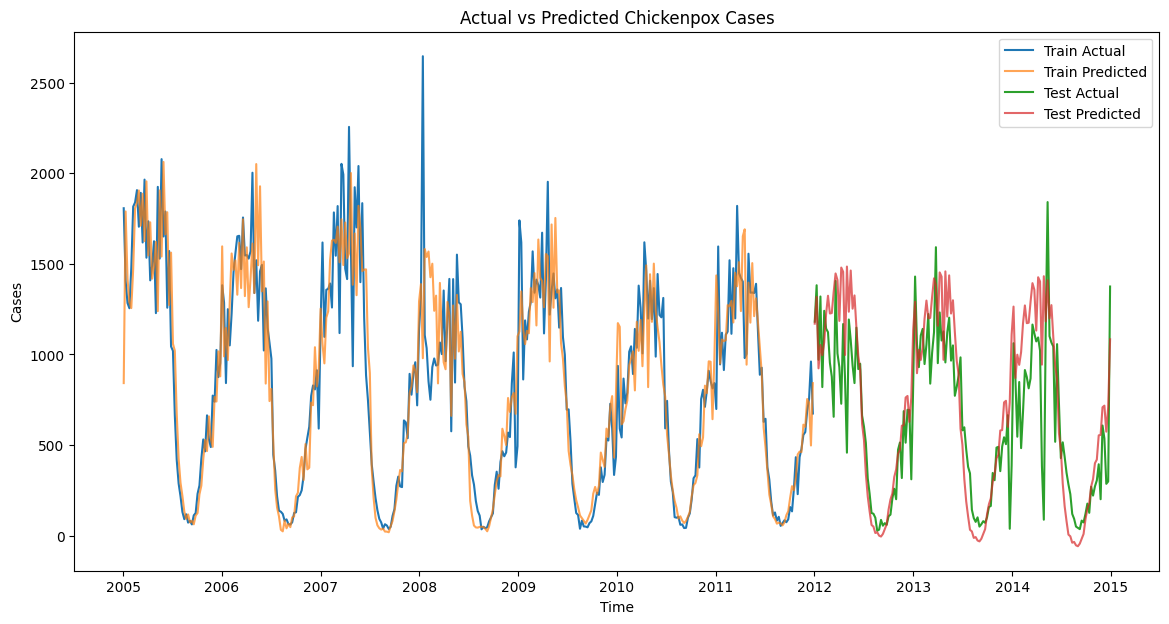

In [264]:
# Model Evaluation
# Calculate metrics
def calculate_metrics(true, pred):
    return {'MAE': mean_absolute_error(true, pred),
            'RMSE': np.sqrt(mean_squared_error(true, pred)),
            'MAPE': np.mean(np.abs((true - pred) / true)) * 100}

print("Train Metrics:", calculate_metrics(train['Total_Cases'], train['Predicted']))
print("Test Metrics:", calculate_metrics(test['Total_Cases'], test['Predicted']))

# Visualize predictions
plt.figure(figsize=(14, 7))
plt.plot(train.index, train['Total_Cases'], label='Train Actual')
plt.plot(train.index, train['Predicted'], label='Train Predicted', alpha=0.7)
plt.plot(test.index, test['Total_Cases'], label='Test Actual')
plt.plot(test.index, test['Predicted'], label='Test Predicted', alpha=0.7)
plt.title('Actual vs Predicted Chickenpox Cases')
plt.xlabel('Time')
plt.ylabel('Cases')
plt.legend()
plt.show()

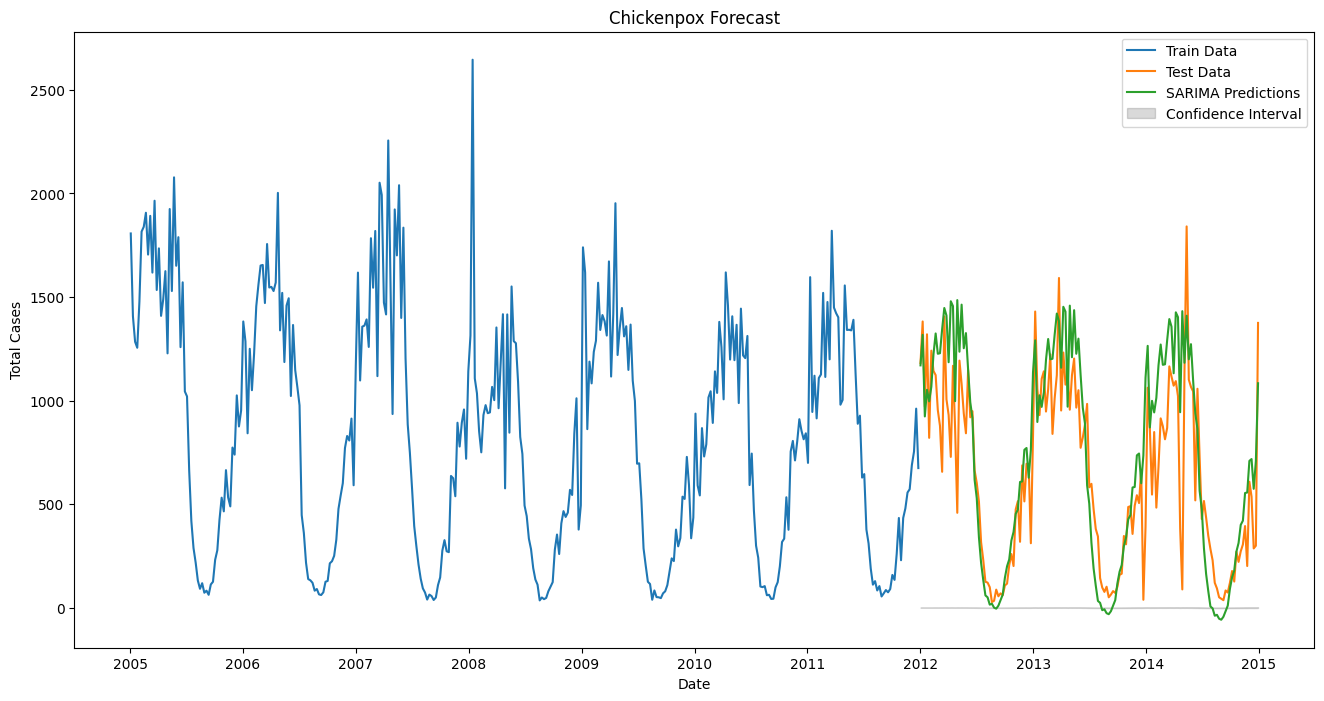

['chickenpox_forecaster.pkl']

In [265]:
# Forecast
forecast = results.get_forecast(steps=len(test))
forecast_ci = forecast.conf_int()

#Plot forecast
plt.figure(figsize=(16, 8))
plt.plot(train.index, train['Total_Cases'], label='Train Data')
plt.plot(test.index, test['Total_Cases'], label='Test Data')
plt.plot(test.index, test['Predicted'], label='SARIMA Predictions')
plt.fill_between(test.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
color='k', alpha=.15, label='Confidence Interval')
plt.title('Chickenpox Forecast')
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.legend()
plt.show()

#Model saving
joblib.dump({
    'model': results,
    'scaler': f_transformer
}, 'chickenpox_forecaster.pkl')

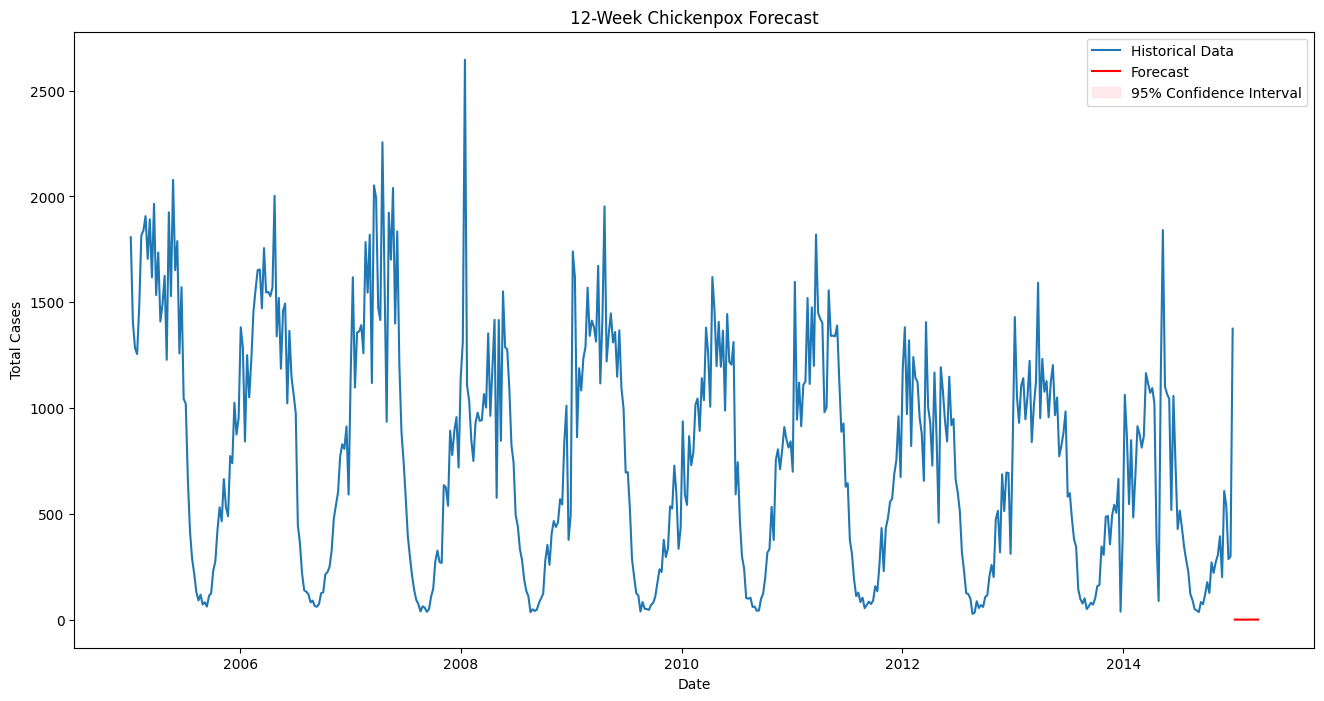

12-Week Forecast:
2015-01-05: 0.31
2015-01-12: 0.45
2015-01-19: 0.08
2015-01-26: 0.20
2015-02-02: 0.15
2015-02-09: 0.21
2015-02-16: 0.36
2015-02-23: 0.46
2015-03-02: 0.36
2015-03-09: 0.37
2015-03-16: 0.48
2015-03-23: 0.57


In [266]:
# Forecast 12 weeks ahead
forecast_steps = 12
forecast = results.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Create future dates for plotting
last_date = cases_df_bk.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps, freq='W-MON')

# Plot the forecast
plt.figure(figsize=(16, 8))
plt.plot(cases_df_bk.index, cases_df_bk['Total_Cases'], label='Historical Data')
plt.plot(future_dates, forecast_mean, color='red', label='Forecast')
plt.fill_between(future_dates,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 color='pink', alpha=0.3, label='95% Confidence Interval')
plt.title('12-Week Chickenpox Forecast')
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.legend()
plt.show()

# Print the forecasted values
print("12-Week Forecast:")
for date, value in zip(future_dates, forecast_mean):
    print(f"{date.date()}: {value:.2f}")


In [267]:
# Save model
import joblib
joblib.dump({
    'model': results,
    'scaler': f_transformer
}, 'chickenpox_forecaster.pkl')

# Load model
forecaster = joblib.load('chickenpox_forecaster.pkl')


CONCLUSION:

The SARIMA (Seasonal Autoregressive Integrated Moving Average) model successfully captures the pronounced seasonal patterns of chickenpox outbreaks observed between 2005 and 2015, as well as the test data occurrences.

The plot reveals that the model is really good at capturing trends, which points to the predictive power of its design, but also suggests a need to improve the way it captures noise because it does not match the actual data at precise weekly points.




ADDON : EXPLORATORY DATA ANALYSIS

In [268]:
def univariate_analysis_numeric(df, column):
    """Perform univariate analysis for numeric variables"""
    plt.figure(figsize=(12, 6))

    # Create subplot grid
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Histogram with KDE
    sns.histplot(df[column], kde=True, ax=ax1)
    ax1.set_title(f'Distribution of {column}')
    ax1.set_xlabel(column)
    ax1.set_ylabel('Frequency')

    # Box plot
    sns.boxplot(y=df[column], ax=ax2)
    ax2.set_title(f'Boxplot of {column}')
    ax2.set_ylabel(column)

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print(f"\nSummary Statistics for {column}:")
    stats = df[column].describe()
    print(stats)

    # Additional statistics
    print(f"Skewness: {df[column].skew():.2f}")
    print(f"Kurtosis: {df[column].kurtosis():.2f}")
    print(f"Missing values: {df[column].isna().sum()} ({df[column].isna().mean():.2%})")
    print(f"Zero values: {(df[column] == 0).sum()} ({(df[column] == 0).mean():.2%})")

def univariate_analysis_categorical(df, column):
    """Perform univariate analysis for categorical variables"""
    plt.figure(figsize=(12, 6))

    # Count plot
    ax = sns.countplot(x=column, data=df)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')

    # Add percentage labels
    total = len(df[column])
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Print frequency table
    value_counts = df[column].value_counts()
    value_percentage = df[column].value_counts(normalize=True) * 100
    freq_table = pd.DataFrame({
        'Count': value_counts,
        'Percentage': value_percentage
    })
    print(f"\nFrequency Table for {column}:")
    print(freq_table)

    # Missing values
    missing = df[column].isna().sum()
    print(f"Missing values: {missing} ({missing/len(df):.2%})")

def univariate_analysis(df, column):
    """Perform univariate analysis based on data type"""
    if df[column].dtype in ['int64', 'float64']:
        univariate_analysis_numeric(df, column)
    else:
        univariate_analysis_categorical(df, column)


<Figure size 1200x600 with 0 Axes>

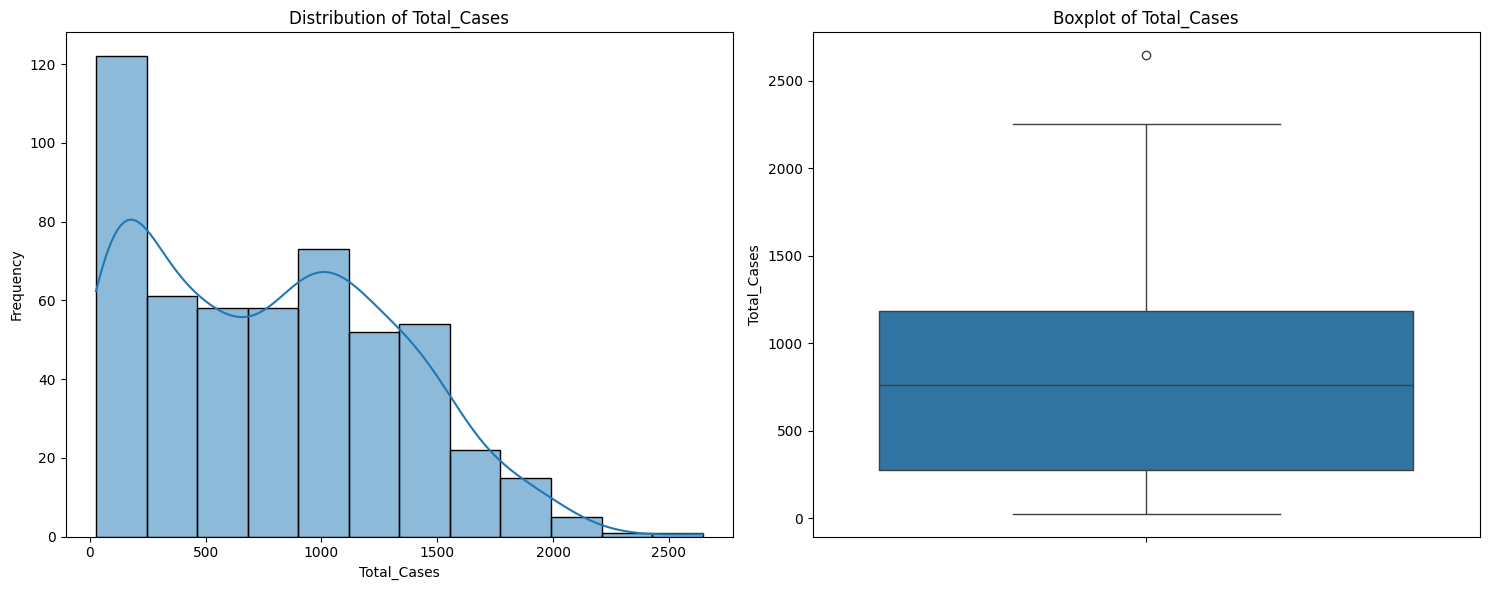


Summary Statistics for Total_Cases:
count     522.000000
mean      776.856322
std       544.253836
min        27.000000
25%       275.500000
50%       762.500000
75%      1184.750000
max      2646.000000
Name: Total_Cases, dtype: float64
Skewness: 0.37
Kurtosis: -0.74
Missing values: 0 (0.00%)
Zero values: 0 (0.00%)


<Figure size 1200x600 with 0 Axes>

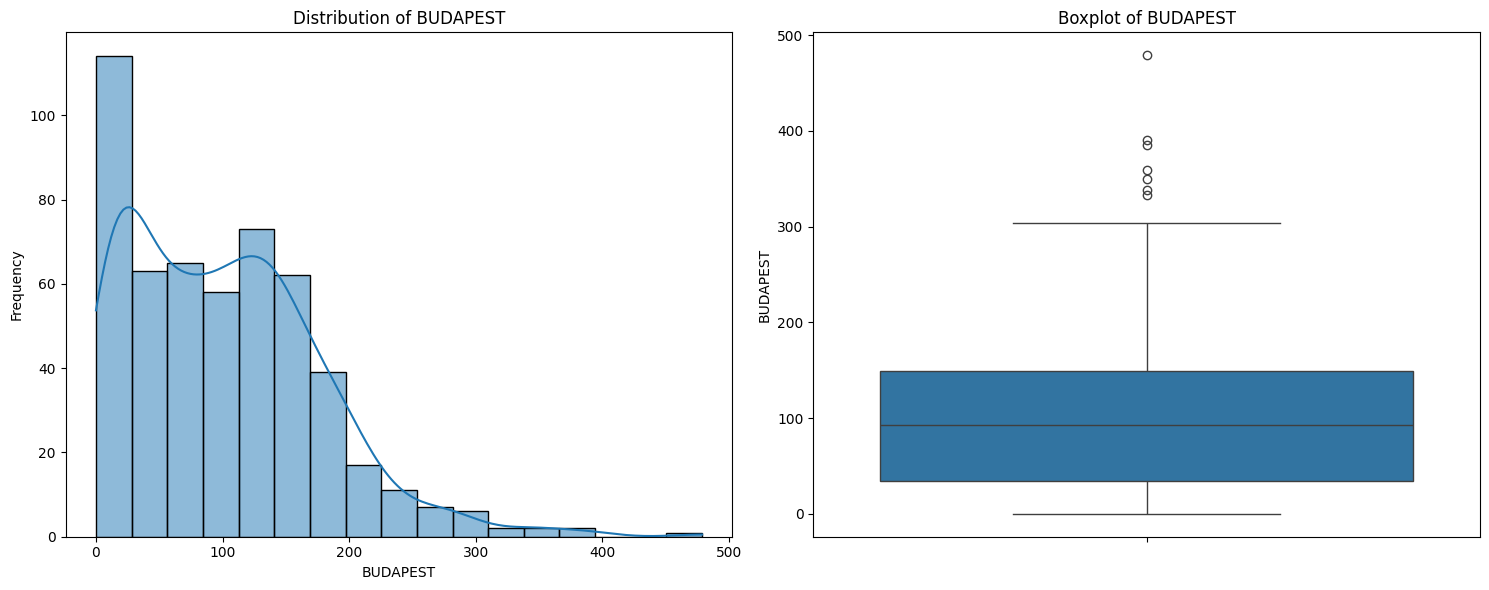


Summary Statistics for BUDAPEST:
count    522.000000
mean     101.245211
std       76.354872
min        0.000000
25%       34.250000
50%       93.000000
75%      149.000000
max      479.000000
Name: BUDAPEST, dtype: float64
Skewness: 0.95
Kurtosis: 1.43
Missing values: 0 (0.00%)
Zero values: 1 (0.19%)


<Figure size 1200x600 with 0 Axes>

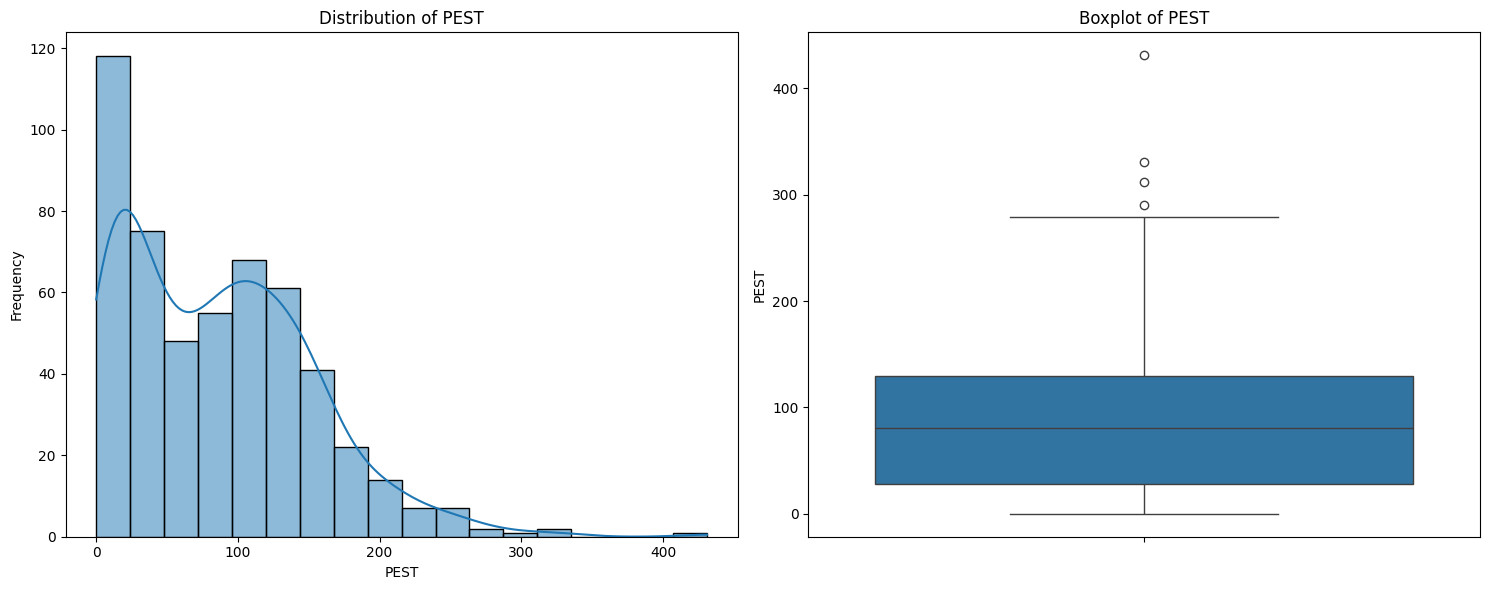


Summary Statistics for PEST:
count    522.000000
mean      86.101533
std       66.773741
min        0.000000
25%       28.250000
50%       81.000000
75%      129.750000
max      431.000000
Name: PEST, dtype: float64
Skewness: 0.87
Kurtosis: 1.15
Missing values: 0 (0.00%)
Zero values: 1 (0.19%)


<Figure size 1200x600 with 0 Axes>

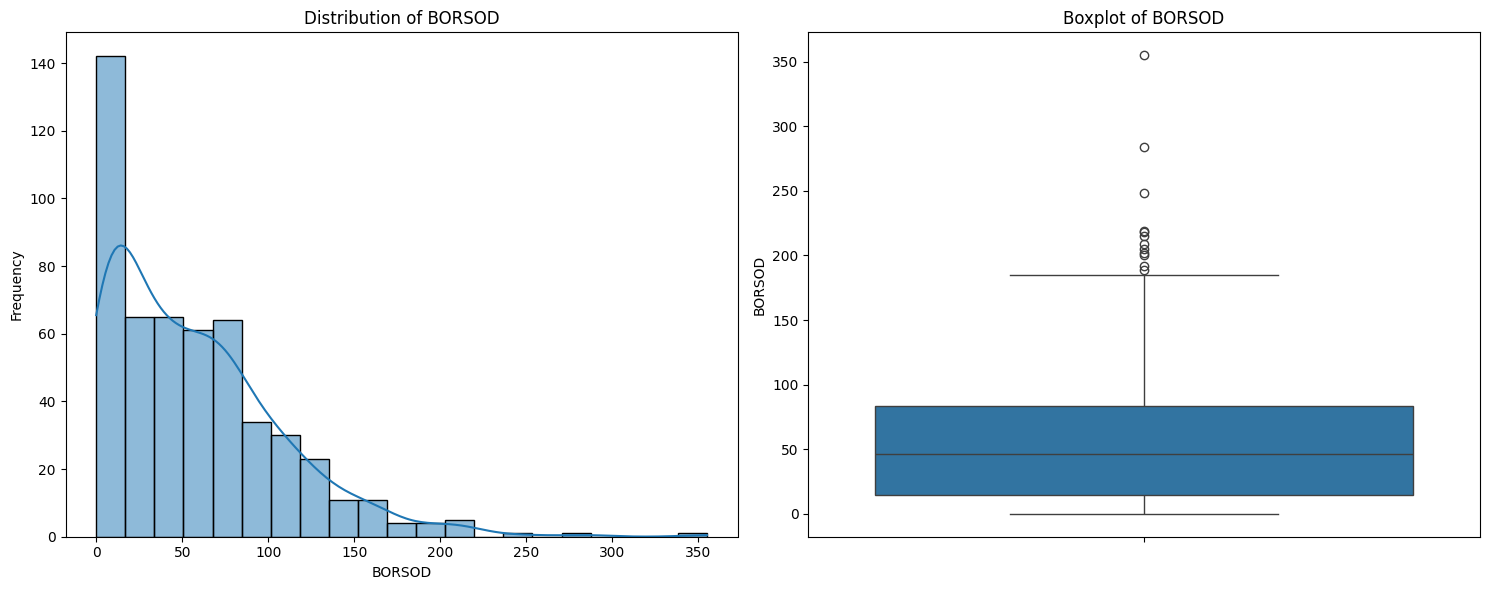


Summary Statistics for BORSOD:
count    522.000000
mean      57.082375
std       50.725437
min        0.000000
25%       14.250000
50%       46.500000
75%       83.750000
max      355.000000
Name: BORSOD, dtype: float64
Skewness: 1.39
Kurtosis: 3.12
Missing values: 0 (0.00%)
Zero values: 3 (0.57%)


<Figure size 1200x600 with 0 Axes>

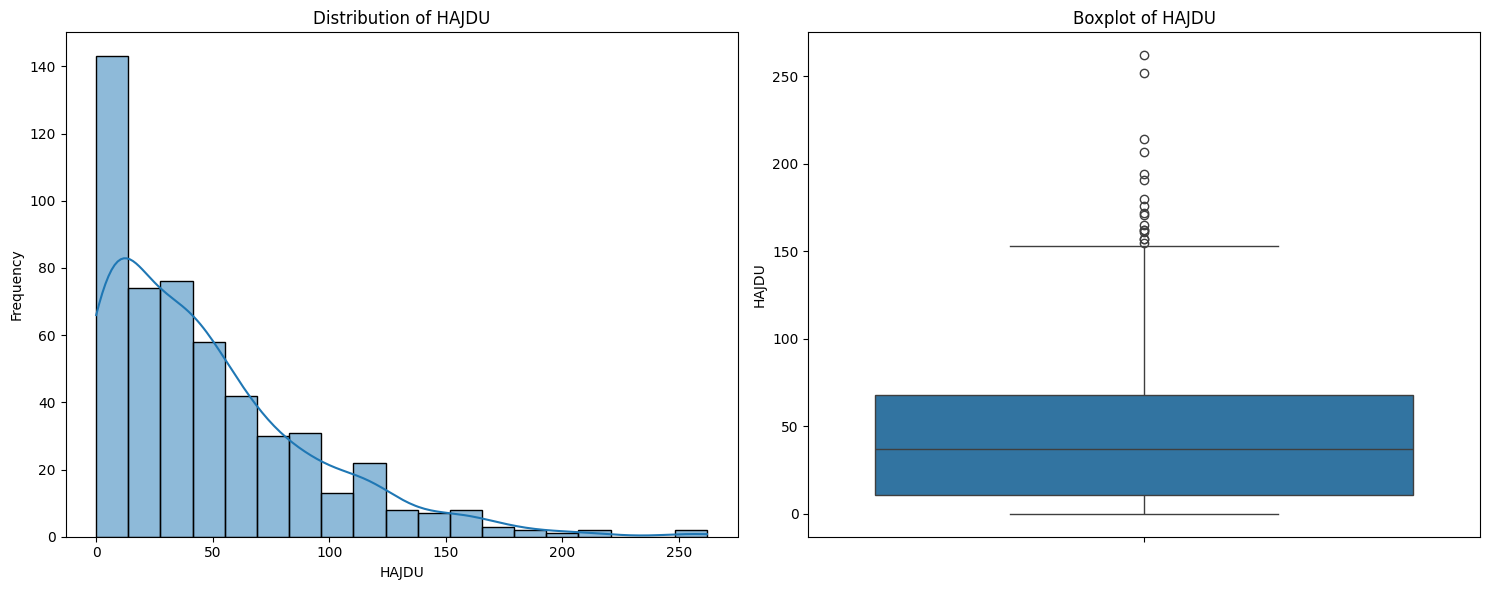


Summary Statistics for HAJDU:
count    522.000000
mean      47.097701
std       44.610836
min        0.000000
25%       11.000000
50%       37.000000
75%       68.000000
max      262.000000
Name: HAJDU, dtype: float64
Skewness: 1.41
Kurtosis: 2.34
Missing values: 0 (0.00%)
Zero values: 15 (2.87%)


<Figure size 1200x600 with 0 Axes>

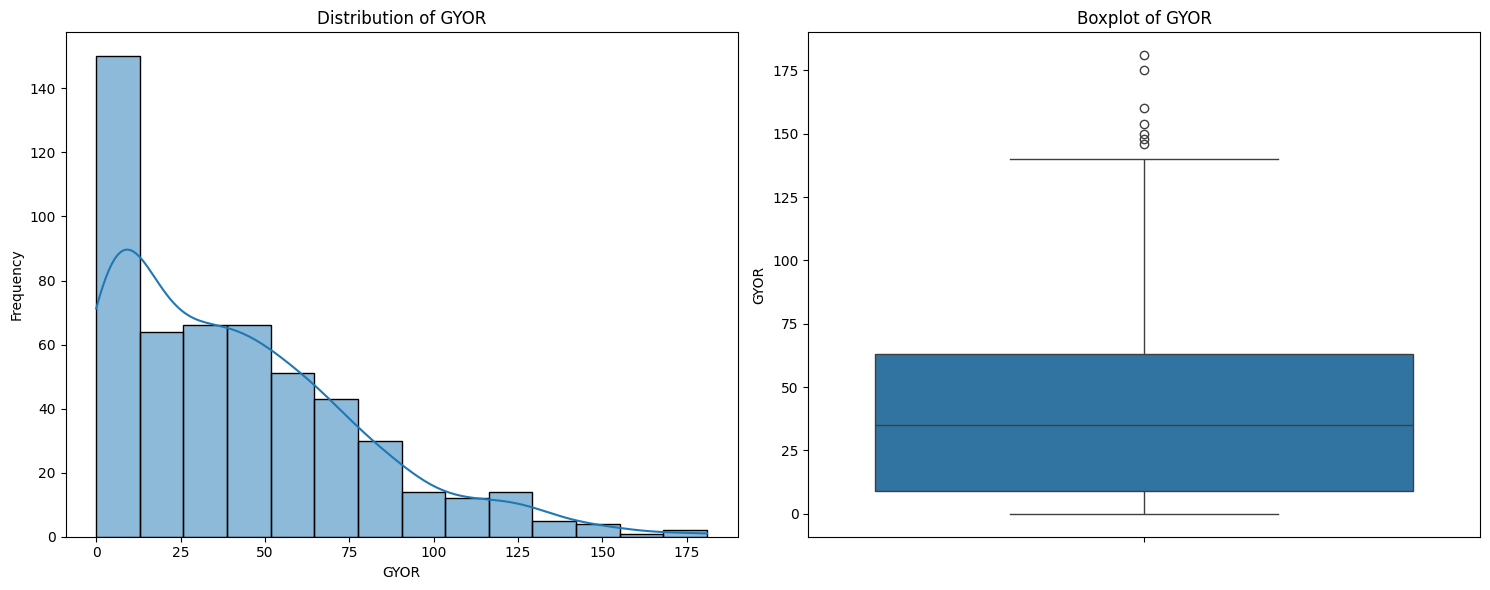


Summary Statistics for GYOR:
count    522.000000
mean      41.436782
std       36.014297
min        0.000000
25%        9.000000
50%       35.000000
75%       63.000000
max      181.000000
Name: GYOR, dtype: float64
Skewness: 1.03
Kurtosis: 0.76
Missing values: 0 (0.00%)
Zero values: 11 (2.11%)


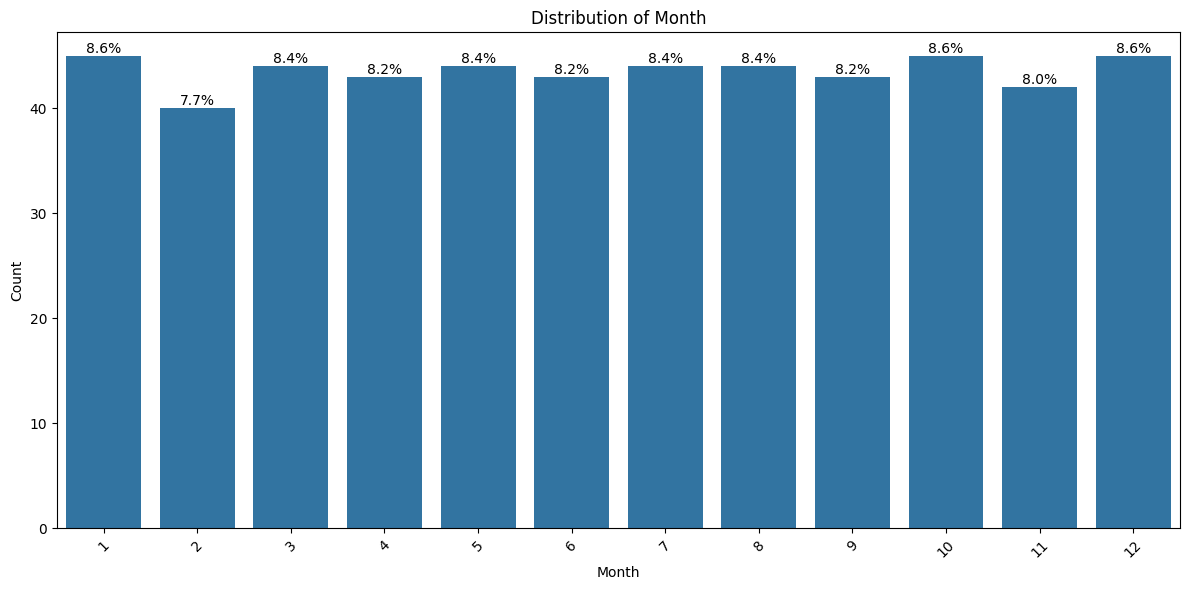


Frequency Table for Month:
       Count  Percentage
Month                   
1         45    8.620690
10        45    8.620690
12        45    8.620690
3         44    8.429119
5         44    8.429119
7         44    8.429119
8         44    8.429119
4         43    8.237548
6         43    8.237548
9         43    8.237548
11        42    8.045977
2         40    7.662835
Missing values: 0 (0.00%)


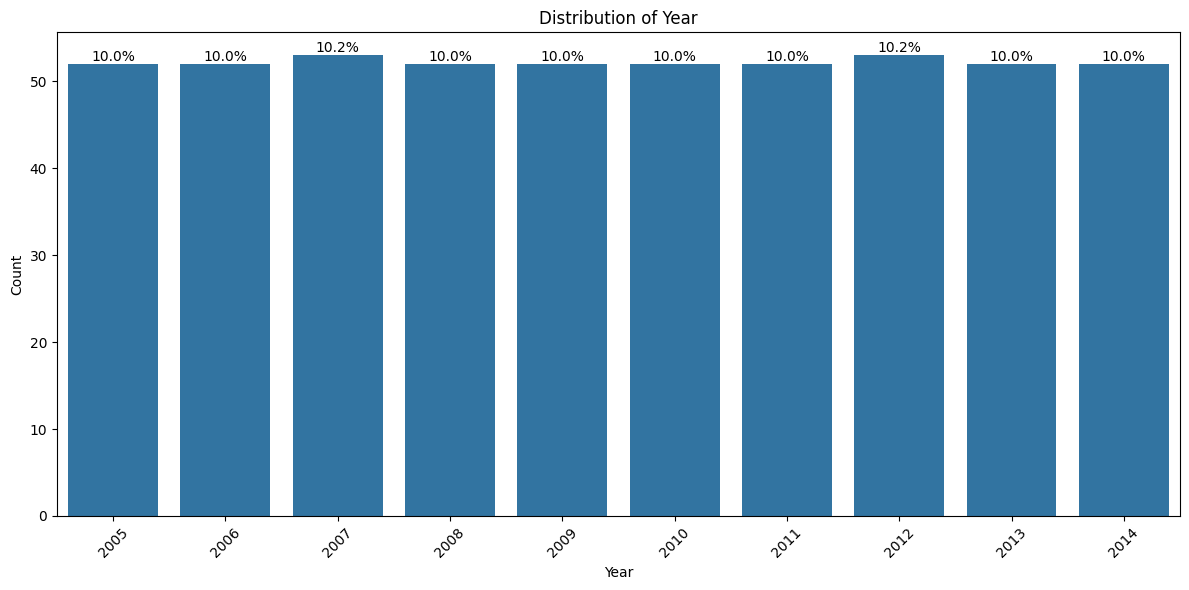


Frequency Table for Year:
      Count  Percentage
Year                   
2007     53   10.153257
2012     53   10.153257
2005     52    9.961686
2006     52    9.961686
2008     52    9.961686
2009     52    9.961686
2010     52    9.961686
2011     52    9.961686
2013     52    9.961686
2014     52    9.961686
Missing values: 0 (0.00%)


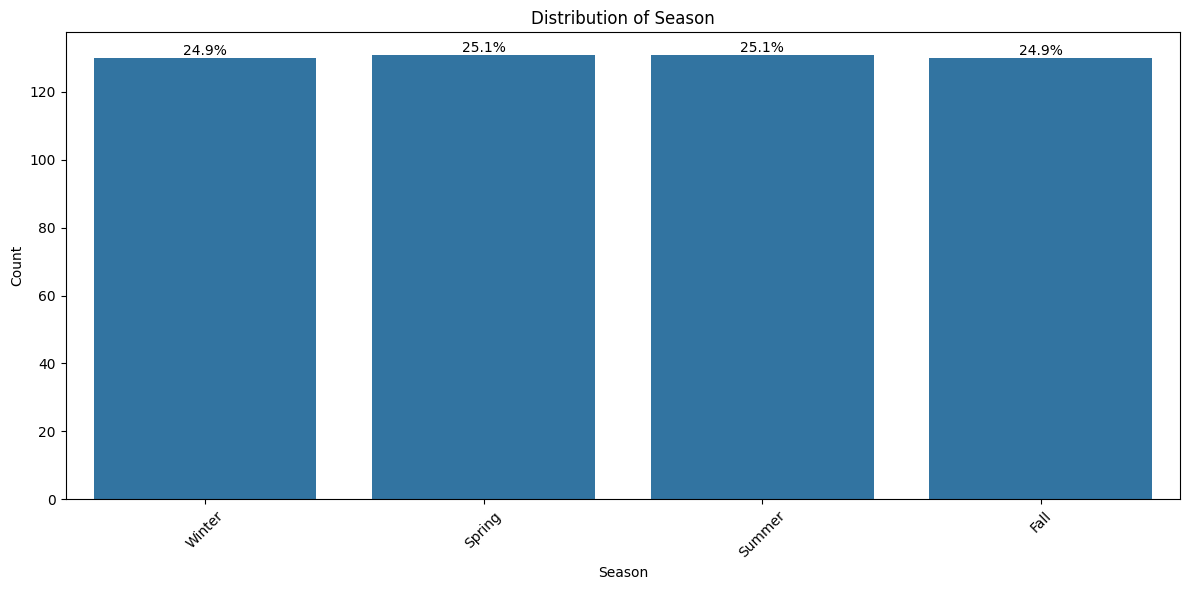


Frequency Table for Season:
        Count  Percentage
Season                   
Spring    131   25.095785
Summer    131   25.095785
Winter    130   24.904215
Fall      130   24.904215
Missing values: 0 (0.00%)


In [269]:
# Extract temporal features
cases_df_bk['Month'] = cases_df_bk.index.month
cases_df_bk['Year'] = cases_df_bk.index.year
cases_df_bk['Season'] = cases_df_bk['Month'].map({1:'Winter', 2:'Winter', 3:'Spring', 4:'Spring', 5:'Spring',
                                                  6:'Summer', 7:'Summer', 8:'Summer',
                                                  9:'Fall', 10:'Fall', 11:'Fall', 12:'Winter'})

# Now perform the analysis
# Analyze total cases
univariate_analysis(cases_df_bk, 'Total_Cases')

# Analyze top counties
top_counties = ['BUDAPEST', 'PEST', 'BORSOD', 'HAJDU', 'GYOR']
for county in top_counties:
    univariate_analysis(cases_df_bk, county)

# Analyze seasonal variables
univariate_analysis(cases_df_bk, 'Month')
univariate_analysis(cases_df_bk, 'Year')
univariate_analysis(cases_df_bk, 'Season')


<Figure size 1200x600 with 0 Axes>

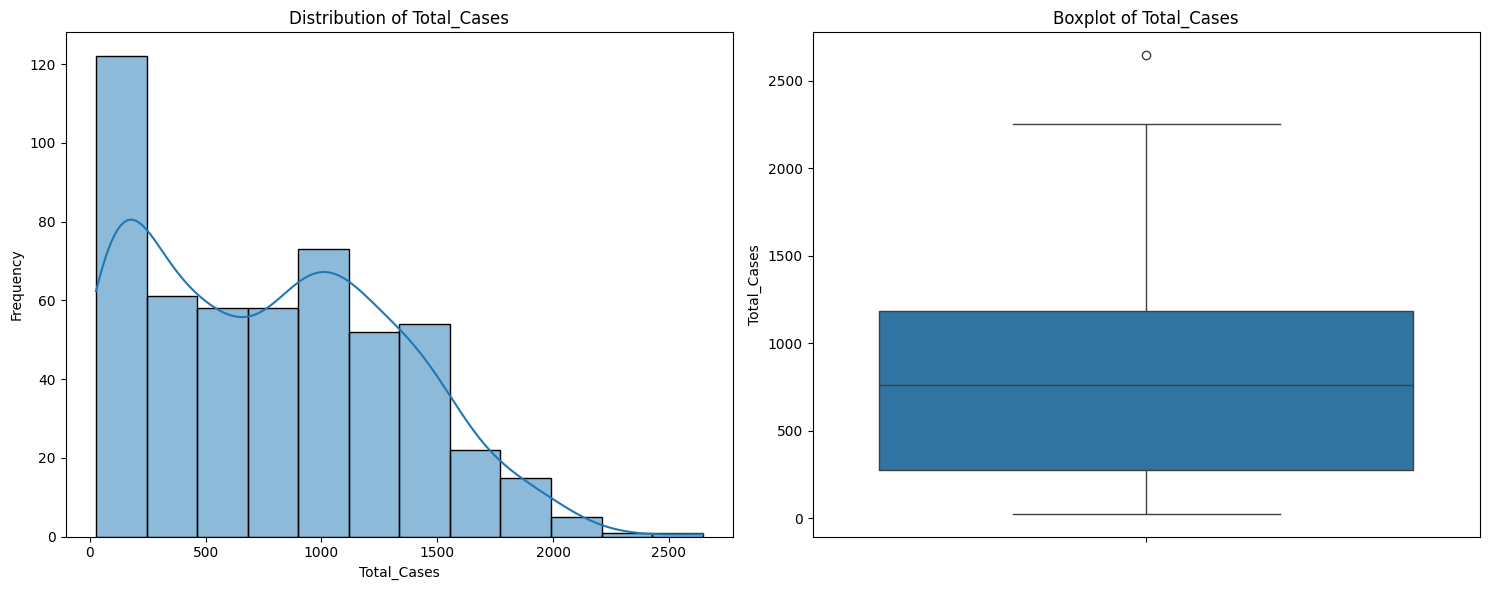


Summary Statistics for Total_Cases:
count     522.000000
mean      776.856322
std       544.253836
min        27.000000
25%       275.500000
50%       762.500000
75%      1184.750000
max      2646.000000
Name: Total_Cases, dtype: float64
Skewness: 0.37
Kurtosis: -0.74
Missing values: 0 (0.00%)
Zero values: 0 (0.00%)


<Figure size 1200x600 with 0 Axes>

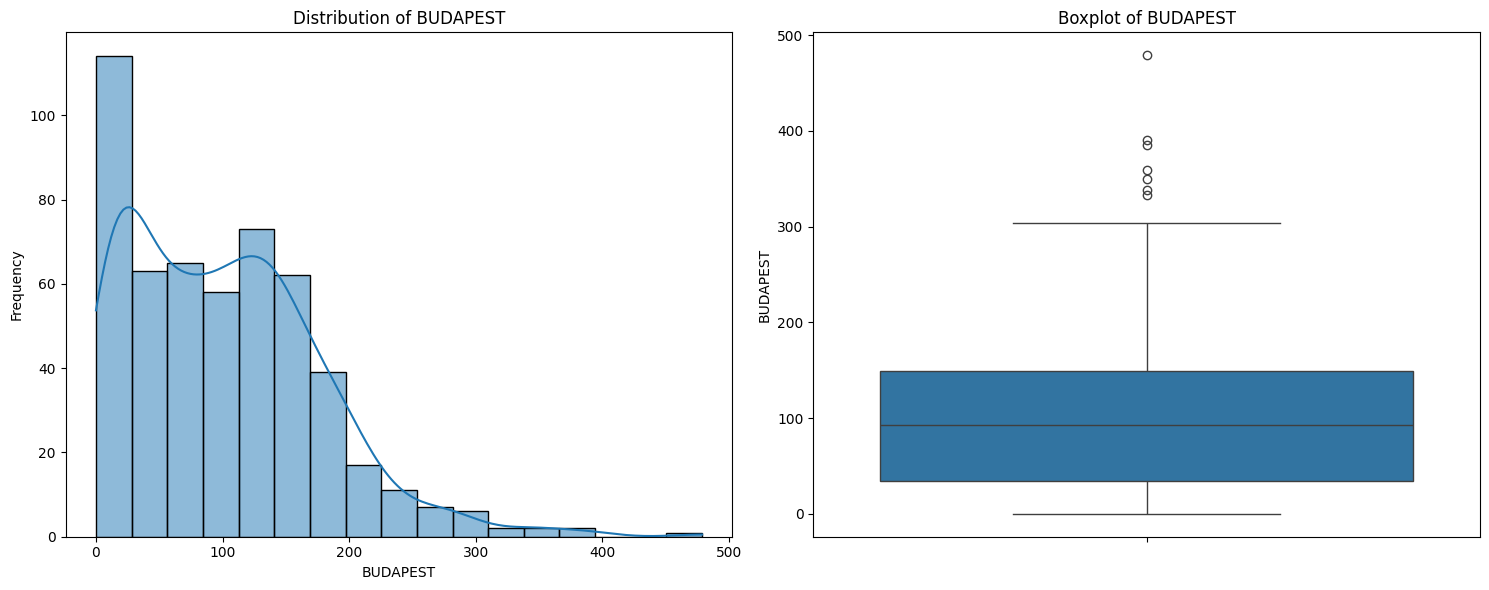


Summary Statistics for BUDAPEST:
count    522.000000
mean     101.245211
std       76.354872
min        0.000000
25%       34.250000
50%       93.000000
75%      149.000000
max      479.000000
Name: BUDAPEST, dtype: float64
Skewness: 0.95
Kurtosis: 1.43
Missing values: 0 (0.00%)
Zero values: 1 (0.19%)


<Figure size 1200x600 with 0 Axes>

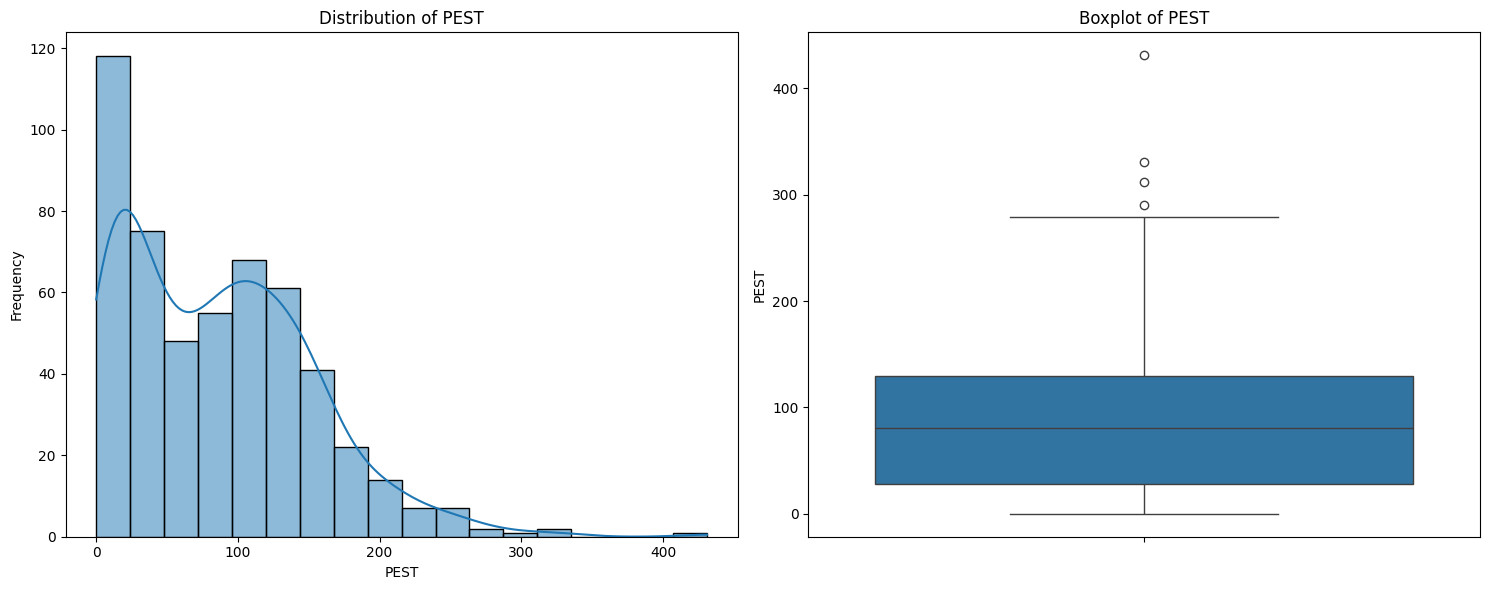


Summary Statistics for PEST:
count    522.000000
mean      86.101533
std       66.773741
min        0.000000
25%       28.250000
50%       81.000000
75%      129.750000
max      431.000000
Name: PEST, dtype: float64
Skewness: 0.87
Kurtosis: 1.15
Missing values: 0 (0.00%)
Zero values: 1 (0.19%)


<Figure size 1200x600 with 0 Axes>

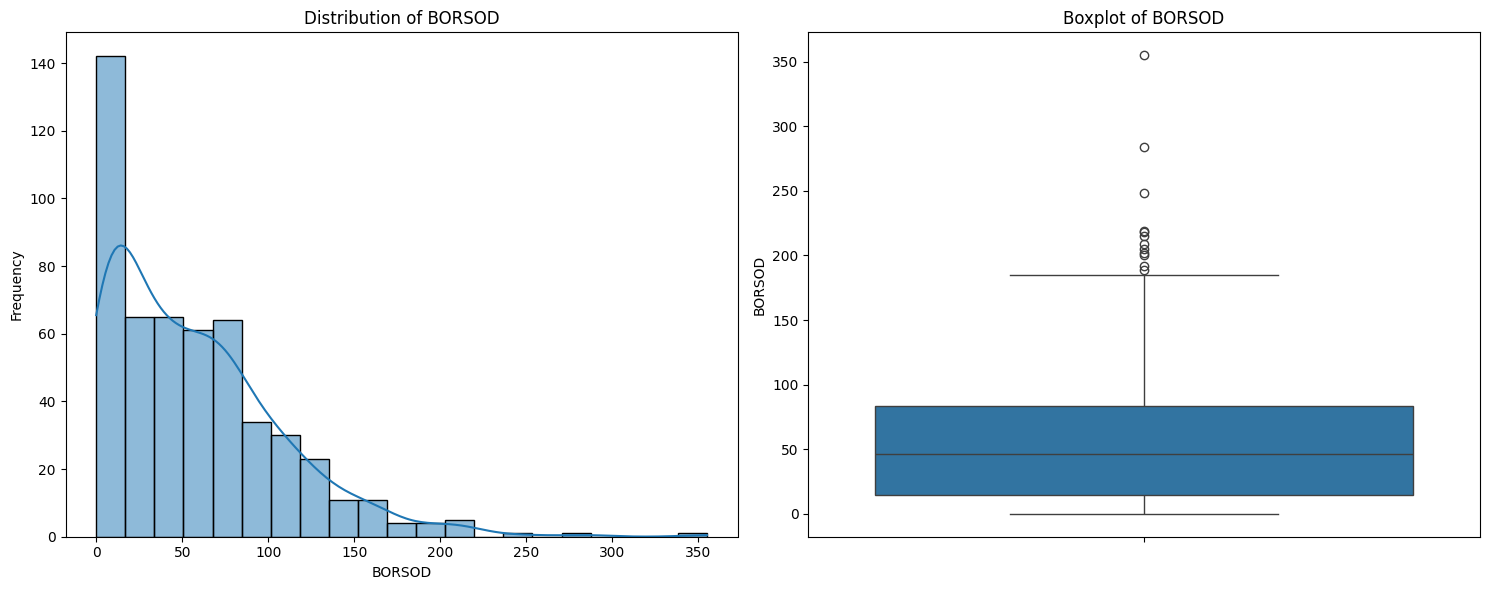


Summary Statistics for BORSOD:
count    522.000000
mean      57.082375
std       50.725437
min        0.000000
25%       14.250000
50%       46.500000
75%       83.750000
max      355.000000
Name: BORSOD, dtype: float64
Skewness: 1.39
Kurtosis: 3.12
Missing values: 0 (0.00%)
Zero values: 3 (0.57%)


<Figure size 1200x600 with 0 Axes>

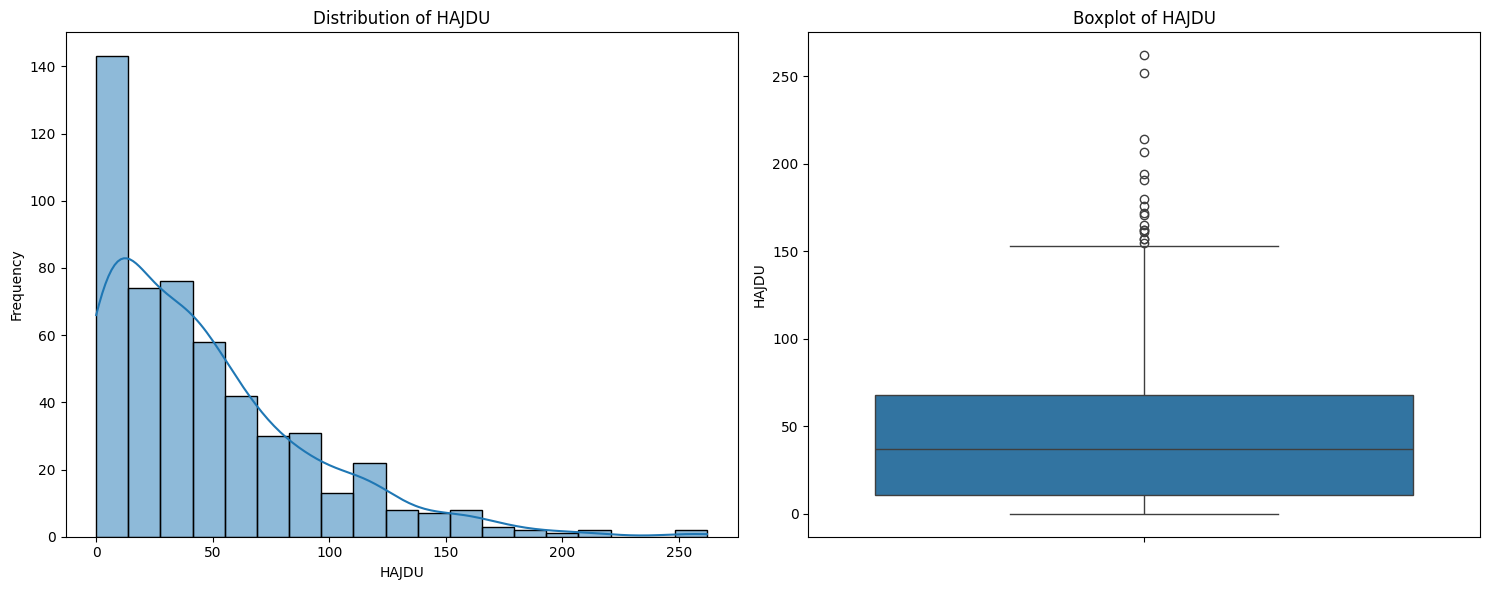


Summary Statistics for HAJDU:
count    522.000000
mean      47.097701
std       44.610836
min        0.000000
25%       11.000000
50%       37.000000
75%       68.000000
max      262.000000
Name: HAJDU, dtype: float64
Skewness: 1.41
Kurtosis: 2.34
Missing values: 0 (0.00%)
Zero values: 15 (2.87%)


<Figure size 1200x600 with 0 Axes>

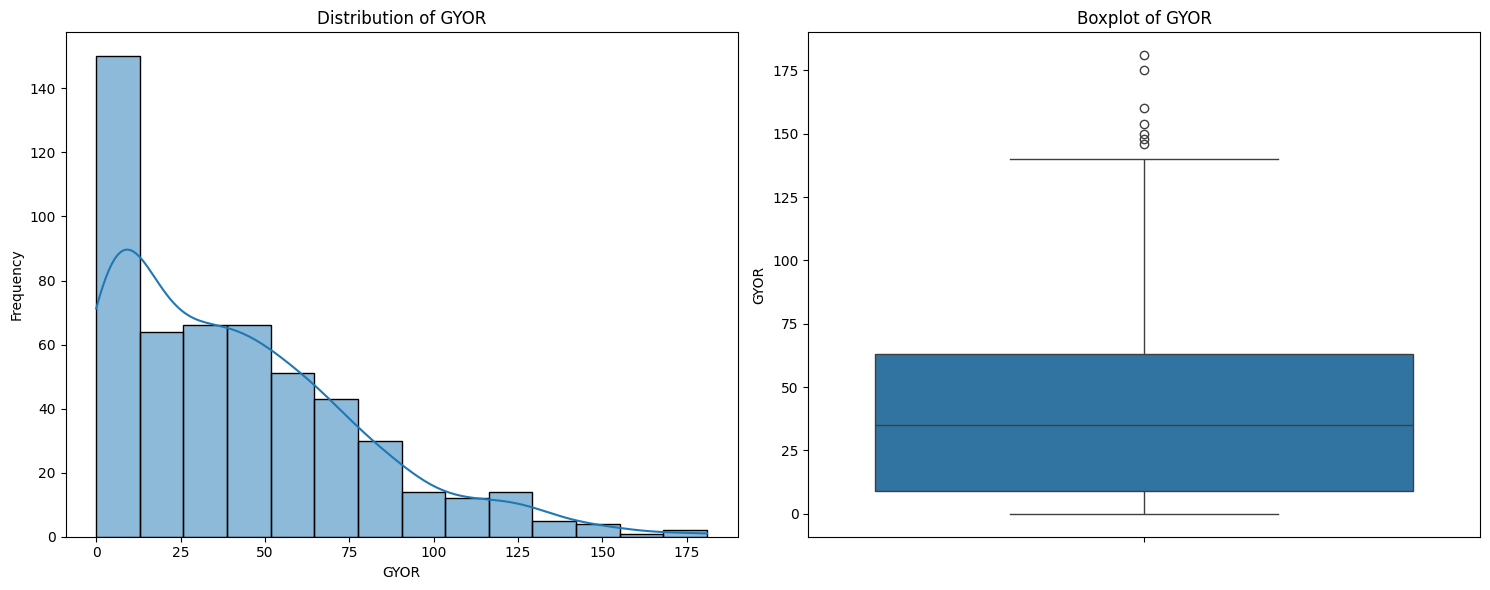


Summary Statistics for GYOR:
count    522.000000
mean      41.436782
std       36.014297
min        0.000000
25%        9.000000
50%       35.000000
75%       63.000000
max      181.000000
Name: GYOR, dtype: float64
Skewness: 1.03
Kurtosis: 0.76
Missing values: 0 (0.00%)
Zero values: 11 (2.11%)


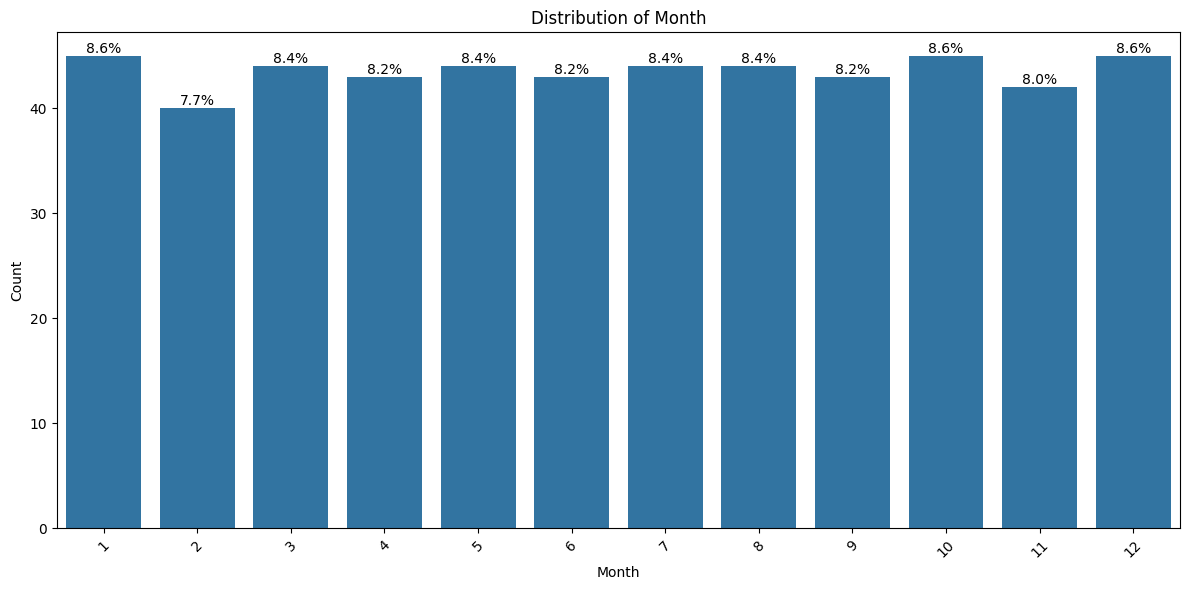


Frequency Table for Month:
       Count  Percentage
Month                   
1         45    8.620690
10        45    8.620690
12        45    8.620690
3         44    8.429119
5         44    8.429119
7         44    8.429119
8         44    8.429119
4         43    8.237548
6         43    8.237548
9         43    8.237548
11        42    8.045977
2         40    7.662835
Missing values: 0 (0.00%)


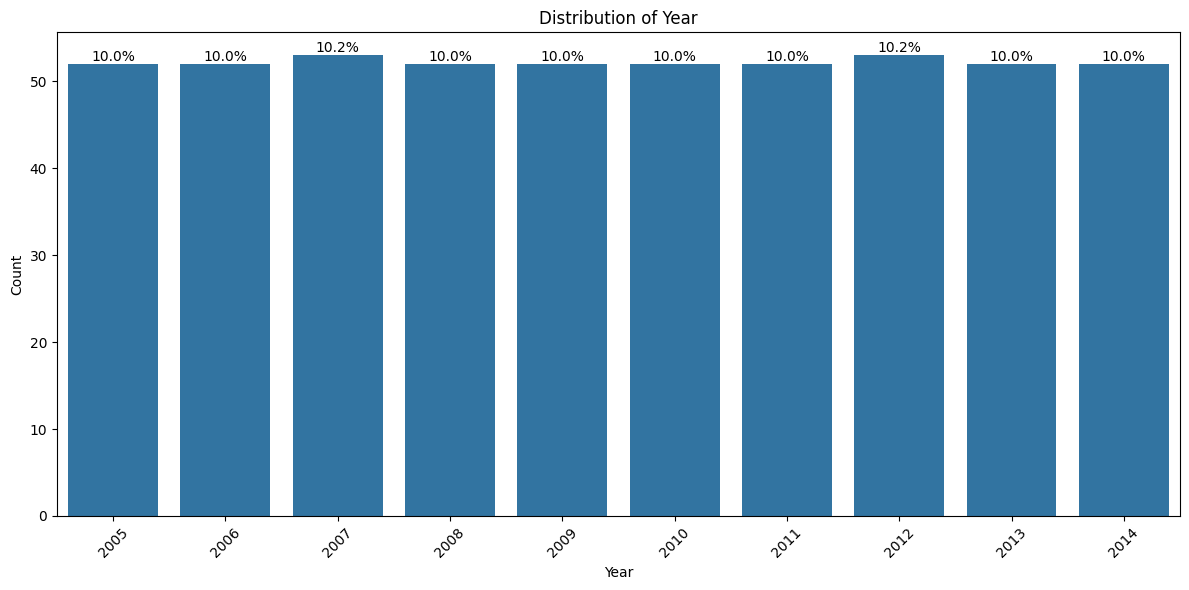


Frequency Table for Year:
      Count  Percentage
Year                   
2007     53   10.153257
2012     53   10.153257
2005     52    9.961686
2006     52    9.961686
2008     52    9.961686
2009     52    9.961686
2010     52    9.961686
2011     52    9.961686
2013     52    9.961686
2014     52    9.961686
Missing values: 0 (0.00%)


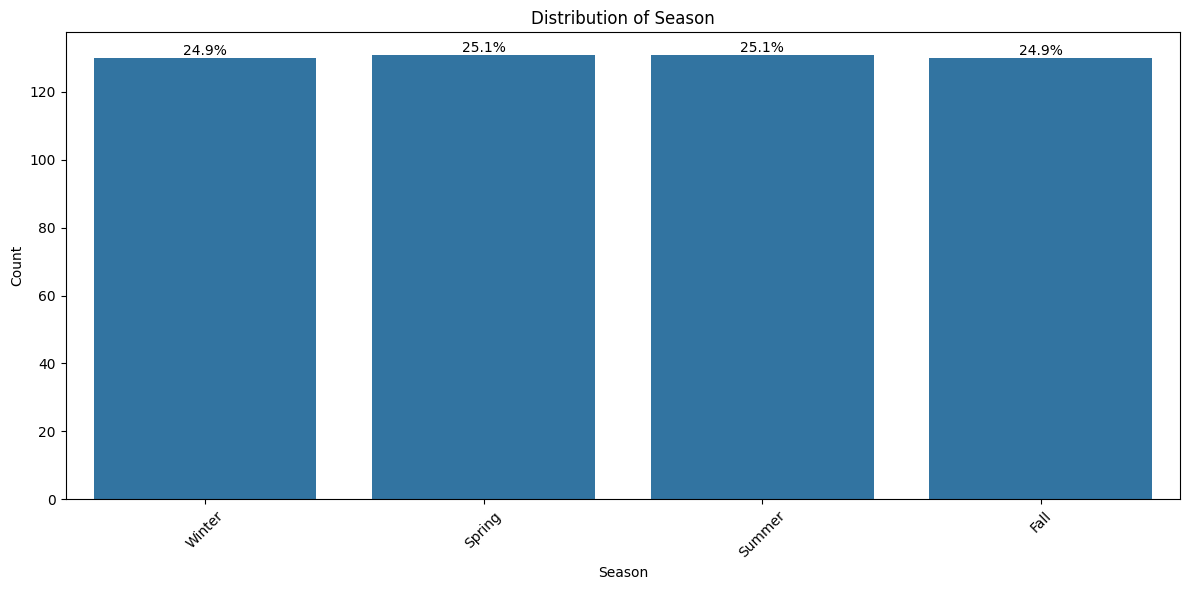


Frequency Table for Season:
        Count  Percentage
Season                   
Spring    131   25.095785
Summer    131   25.095785
Winter    130   24.904215
Fall      130   24.904215
Missing values: 0 (0.00%)


In [270]:
# Extract temporal features
cases_df_bk['Month'] = cases_df_bk.index.month
cases_df_bk['Year'] = cases_df_bk.index.year
cases_df_bk['Season'] = cases_df_bk['Month'].map({1:'Winter', 2:'Winter', 3:'Spring', 4:'Spring', 5:'Spring',
                                                  6:'Summer', 7:'Summer', 8:'Summer',
                                                  9:'Fall', 10:'Fall', 11:'Fall', 12:'Winter'})

# Now perform the analysis
# Analyze total cases
univariate_analysis(cases_df_bk, 'Total_Cases')

# Analyze top counties
top_counties = ['BUDAPEST', 'PEST', 'BORSOD', 'HAJDU', 'GYOR']
for county in top_counties:
    univariate_analysis(cases_df_bk, county)

# Analyze seasonal variables
univariate_analysis(cases_df_bk, 'Month')
univariate_analysis(cases_df_bk, 'Year')
univariate_analysis(cases_df_bk, 'Season')


In [271]:
def bivariate_analysis_numeric_numeric(df, x_column, y_column):
    """Analyze relationship between two numeric variables"""
    plt.figure(figsize=(15, 6))
    # Create subplot grid
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    # Scatter plot
    sns.scatterplot(x=x_column, y=y_column, data=df, ax=ax1)
    ax1.set_title(f'Scatter Plot: {x_column} vs {y_column}')
    ax1.set_xlabel(x_column)
    ax1.set_ylabel(y_column)
    # Joint plot on second axis
    sns.regplot(x=x_column, y=y_column, data=df, scatter_kws={'alpha':0.5}, ax=ax2)
    ax2.set_title(f'Regression Plot: {x_column} vs {y_column}')
    ax2.set_xlabel(x_column)
    ax2.set_ylabel(y_column)
    plt.tight_layout()
    plt.show()
    # Calculate correlation
    correlation = df[x_column].corr(df[y_column])
    print(f"\nCorrelation between {x_column} and {y_column}: {correlation:.4f}")
    # Interpret correlation strength
    if abs(correlation) < 0.3:
        strength = "weak"
    elif abs(correlation) < 0.7:
        strength = "moderate"
    else:
        strength = "strong"
    direction = "positive" if correlation >= 0 else "negative"
    print(f"This indicates a {strength} {direction} relationship.")

def bivariate_analysis_numeric_categorical(df, numeric_col, categorical_col):
    """Analyze relationship between numeric and categorical variables"""
    plt.figure(figsize=(15, 6))
    # Create subplot grid
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    # Box plot
    sns.boxplot(x=categorical_col, y=numeric_col, data=df, ax=ax1)
    ax1.set_title(f'Boxplot of {numeric_col} by {categorical_col}')
    ax1.set_xlabel(categorical_col)
    ax1.set_ylabel(numeric_col)
    # Violin plot
    sns.violinplot(x=categorical_col, y=numeric_col, data=df, ax=ax2)
    ax2.set_title(f'Violin Plot of {numeric_col} by {categorical_col}')
    ax2.set_xlabel(categorical_col)
    ax2.set_ylabel(numeric_col)
    plt.tight_layout()
    plt.show()
    # Group statistics
    group_stats = df.groupby(categorical_col)[numeric_col].agg(['mean', 'median', 'std'])
    print(f"\nGroup Statistics for {numeric_col} by {categorical_col}:")
    print(group_stats)
    # ANOVA for statistical significance
    from scipy import stats
    groups = [df[df[categorical_col] == val][numeric_col].dropna() for val in df[categorical_col].unique()]
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"\nANOVA test: F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")
    if p_value < 0.05:
        print(f"The difference in {numeric_col} across {categorical_col} groups is statistically significant.")
    else:
        print(f"The difference in {numeric_col} across {categorical_col} groups is not statistically significant.")

def bivariate_analysis_categorical_categorical(df, x_column, y_column):
    """Analyze relationship between two categorical variables"""
    # Create crosstab
    crosstab = pd.crosstab(df[x_column], df[y_column])
    # Chi-square test
    from scipy import stats
    chi2, p, dof, expected = stats.chi2_contingency(crosstab)
    # Plot heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f'Crosstab of {x_column} vs {y_column}')
    plt.xlabel(y_column)
    plt.ylabel(x_column)
    plt.tight_layout()
    plt.show()
    # Plot percentage heatmap
    plt.figure(figsize=(12, 8))
    percentage_crosstab = pd.crosstab(df[x_column], df[y_column], normalize='index') * 100
    sns.heatmap(percentage_crosstab, annot=True, fmt='.1f', cmap='YlGnBu')
    plt.title(f'Percentage Crosstab of {x_column} vs {y_column} (row %)')
    plt.xlabel(y_column)
    plt.ylabel(x_column)
    plt.tight_layout()
    plt.show()
    print(f"\nCrosstab of {x_column} vs {y_column}:")
    print(crosstab)
    print(f"\nChi-square test: chi2 = {chi2:.4f}, p-value = {p:.4f}, degrees of freedom = {dof}")
    if p < 0.05:
        print(f"There is a statistically significant association between {x_column} and {y_column}.")
    else:
        print(f"There is no statistically significant association between {x_column} and {y_column}.")

def bivariate_analysis(df, x_column, y_column):
    """Perform bivariate analysis based on data types"""
    x_is_numeric = df[x_column].dtype in ['int64', 'float64']
    y_is_numeric = df[y_column].dtype in ['int64', 'float64']
    if x_is_numeric and y_is_numeric:
        bivariate_analysis_numeric_numeric(df, x_column, y_column)
    elif x_is_numeric and not y_is_numeric:
        bivariate_analysis_numeric_categorical(df, x_column, y_column)
    elif not x_is_numeric and y_is_numeric:
        bivariate_analysis_numeric_categorical(df, y_column, x_column)
    else:
        bivariate_analysis_categorical_categorical(df, x_column, y_column)


<Figure size 1500x600 with 0 Axes>

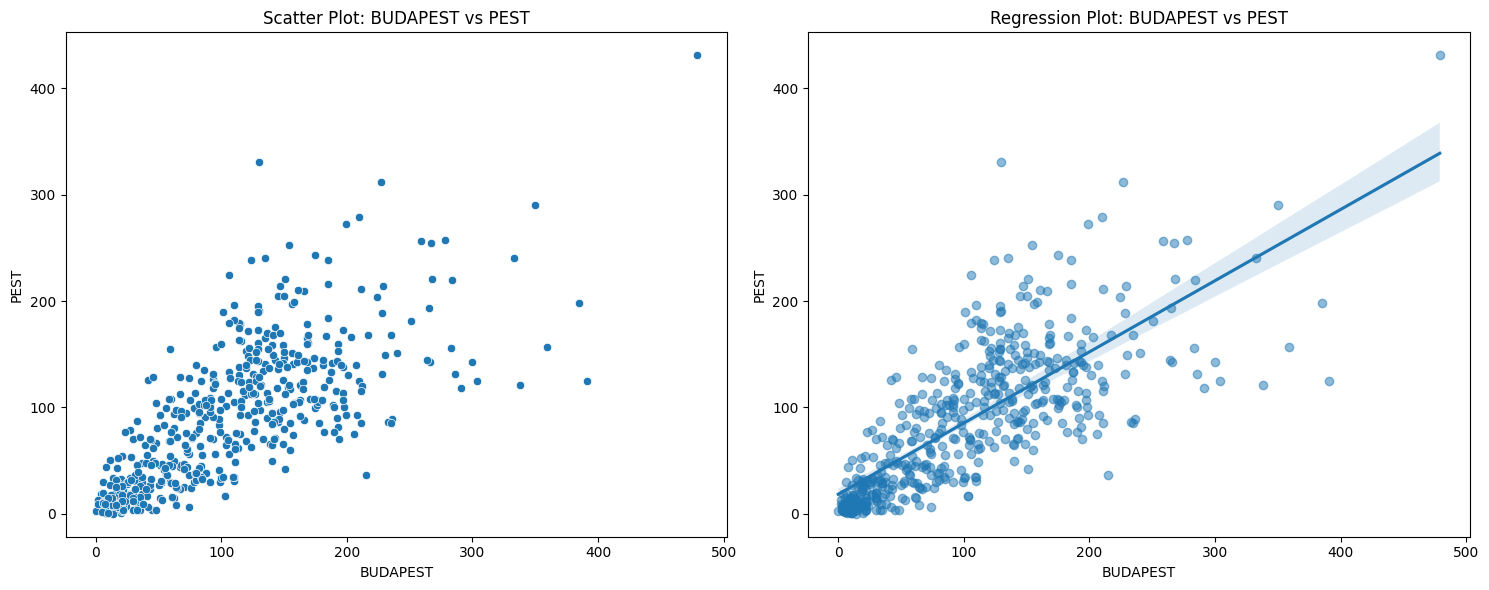


Correlation between BUDAPEST and PEST: 0.7651
This indicates a strong positive relationship.


<Figure size 1500x600 with 0 Axes>

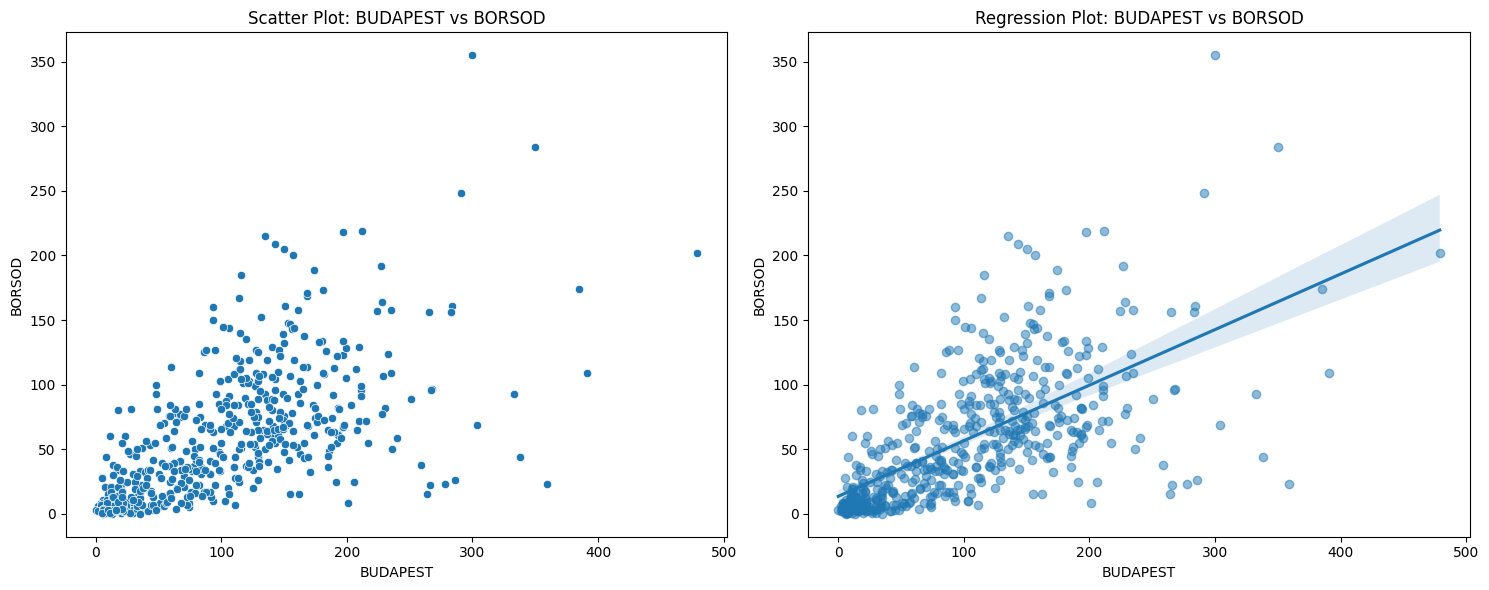


Correlation between BUDAPEST and BORSOD: 0.6476
This indicates a moderate positive relationship.


<Figure size 1500x600 with 0 Axes>

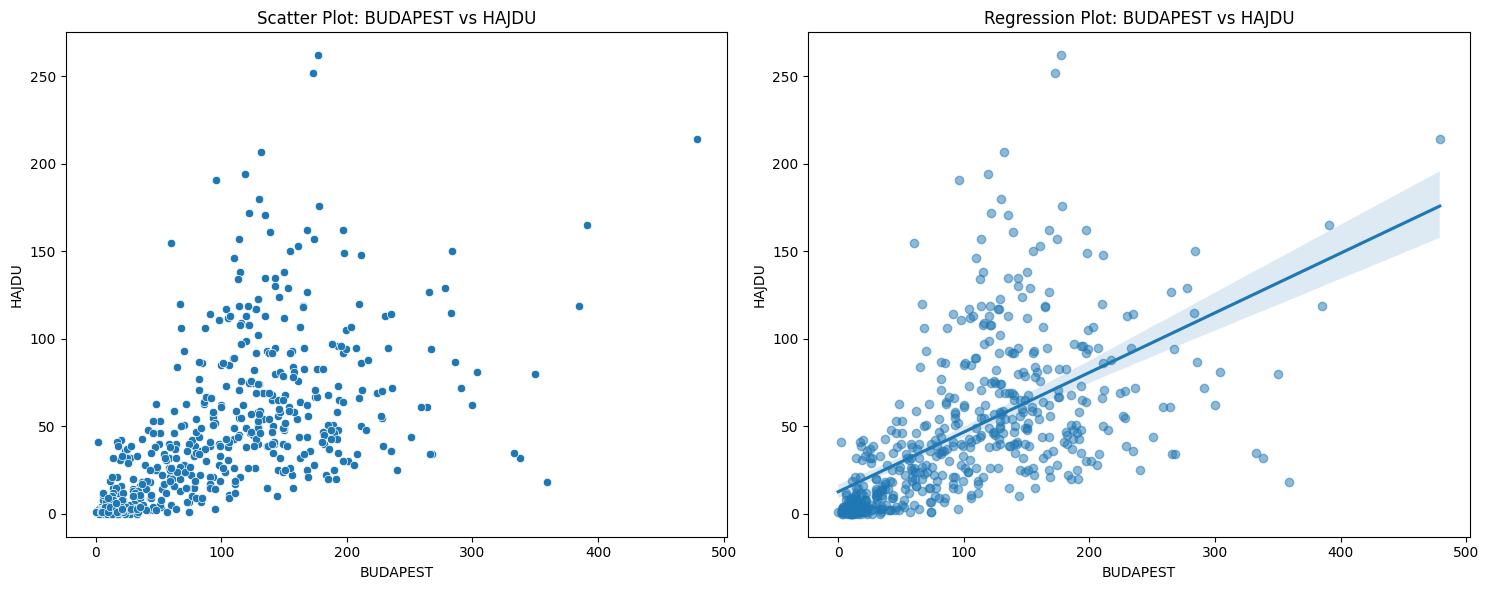


Correlation between BUDAPEST and HAJDU: 0.5832
This indicates a moderate positive relationship.


<Figure size 1500x600 with 0 Axes>

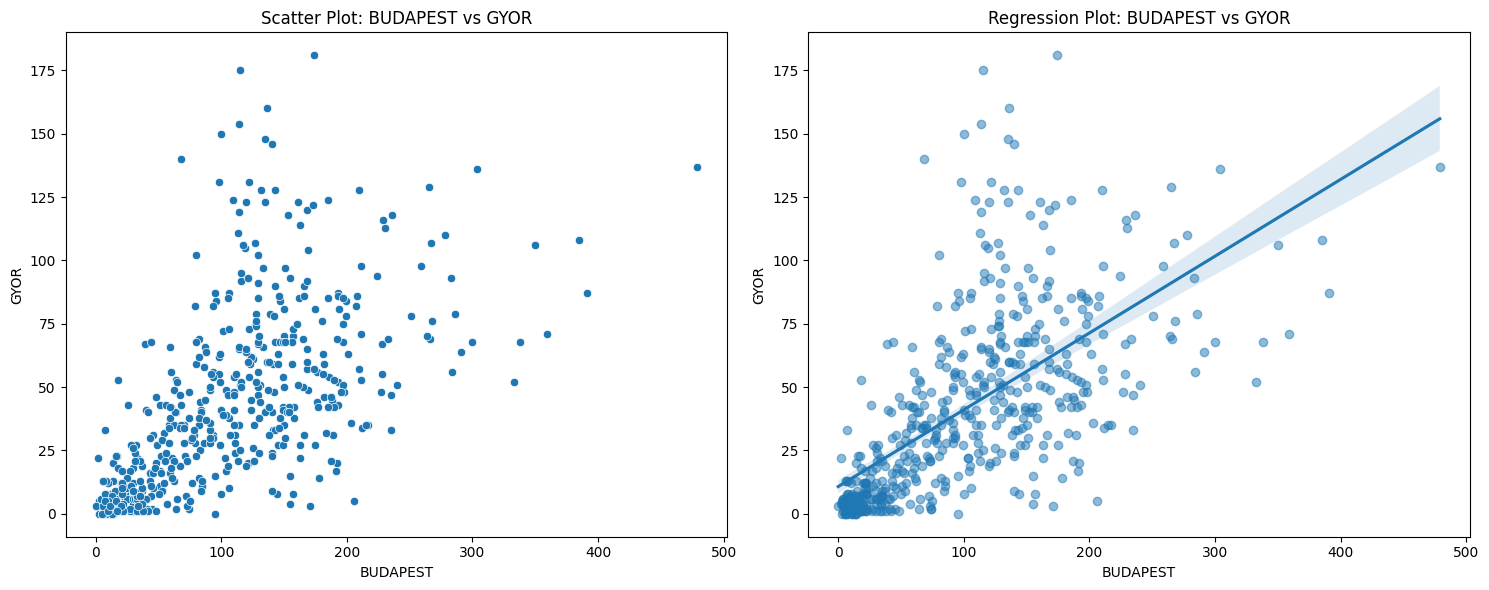


Correlation between BUDAPEST and GYOR: 0.6426
This indicates a moderate positive relationship.


<Figure size 1500x600 with 0 Axes>

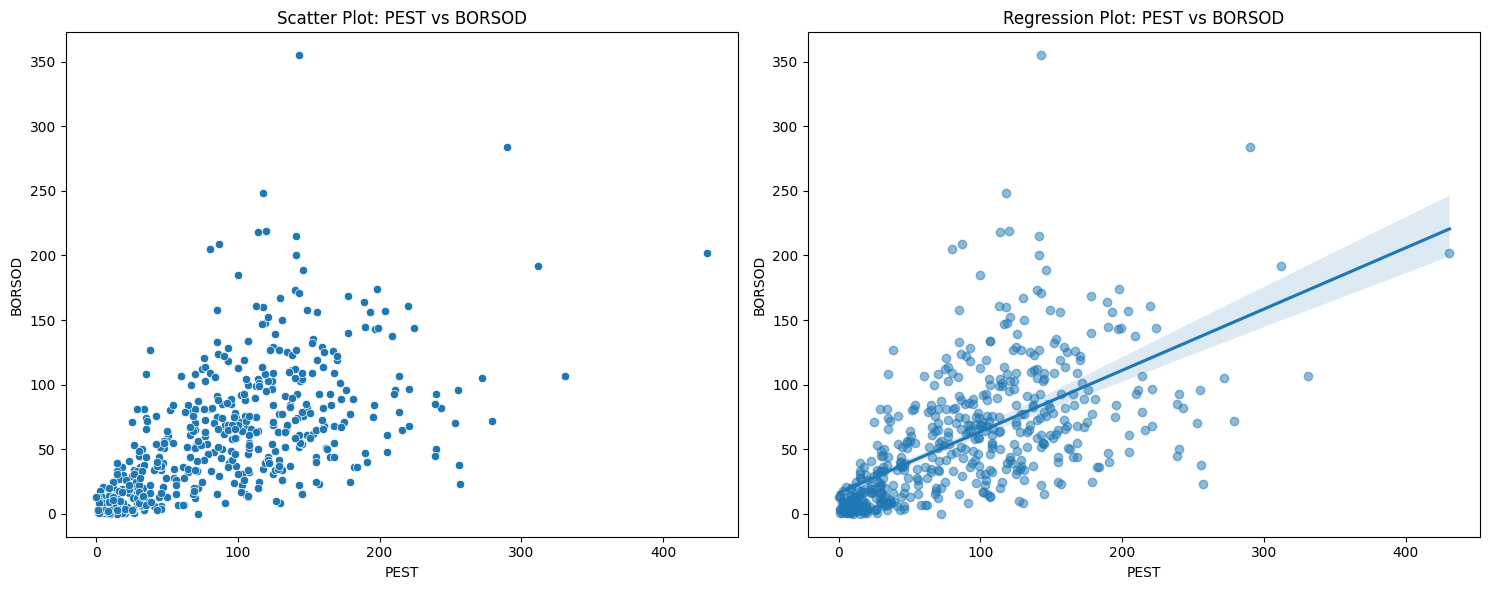


Correlation between PEST and BORSOD: 0.6239
This indicates a moderate positive relationship.


<Figure size 1500x600 with 0 Axes>

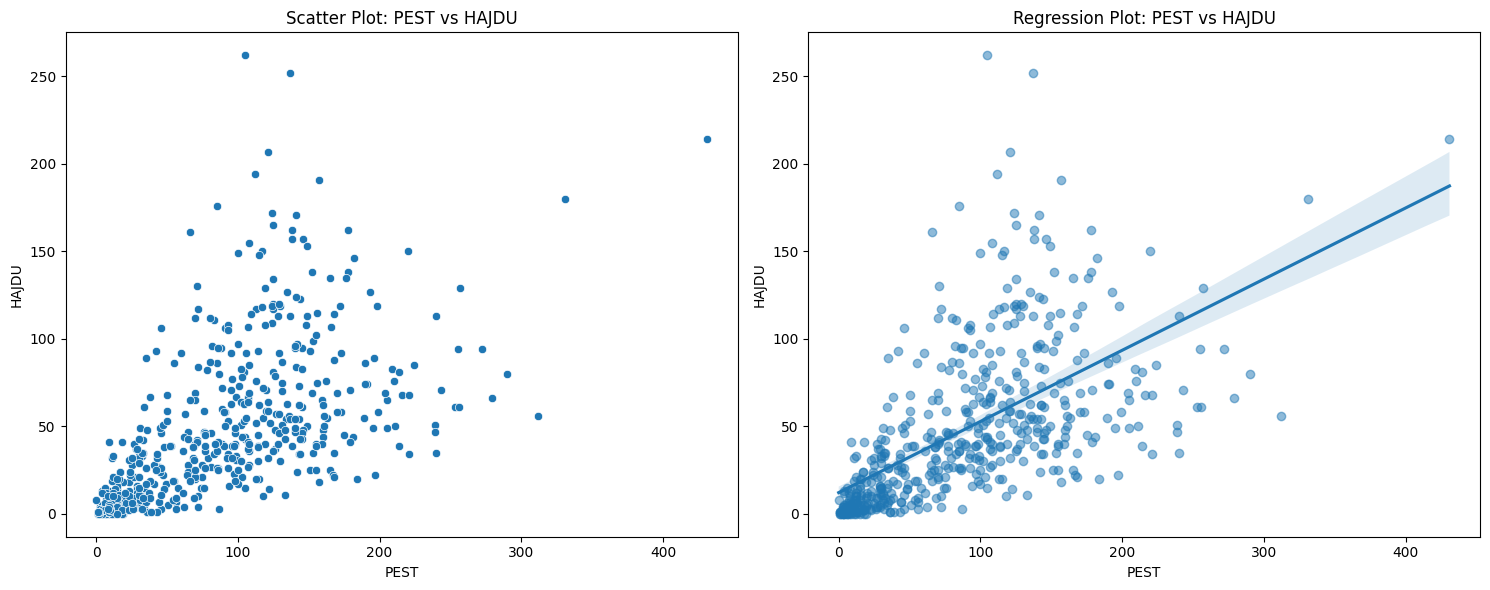


Correlation between PEST and HAJDU: 0.6085
This indicates a moderate positive relationship.


<Figure size 1500x600 with 0 Axes>

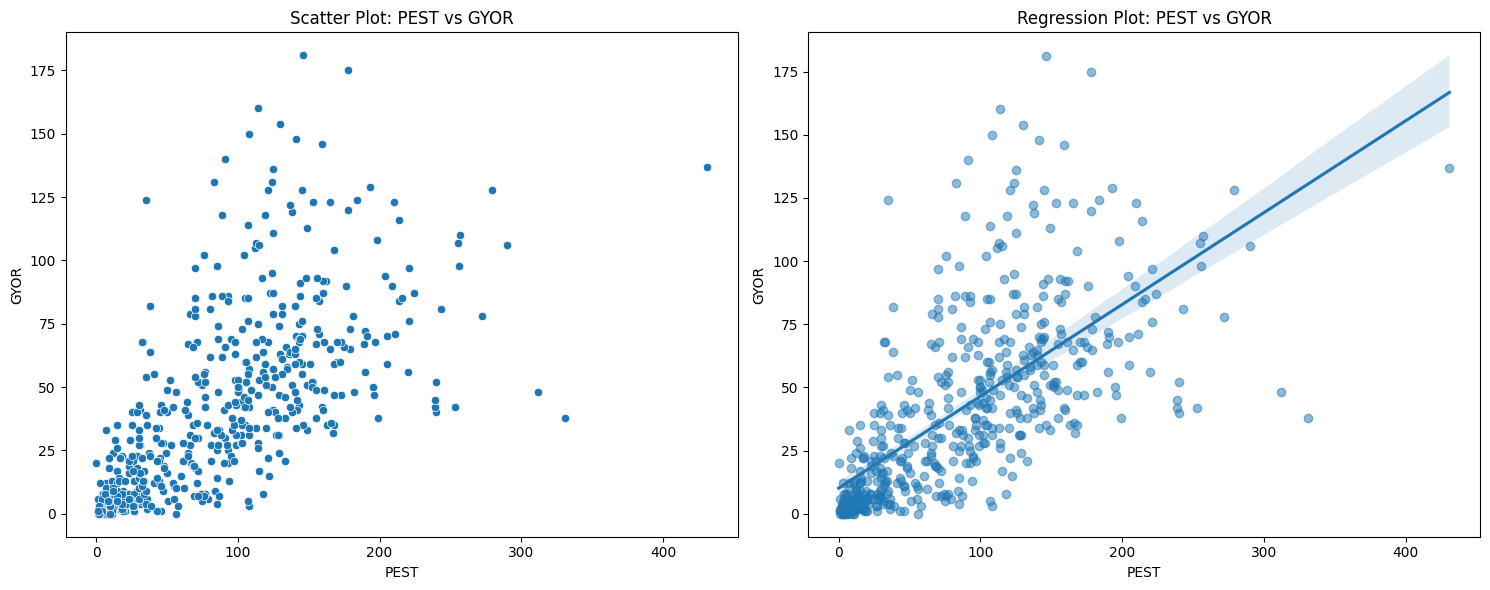


Correlation between PEST and GYOR: 0.6736
This indicates a moderate positive relationship.


<Figure size 1500x600 with 0 Axes>

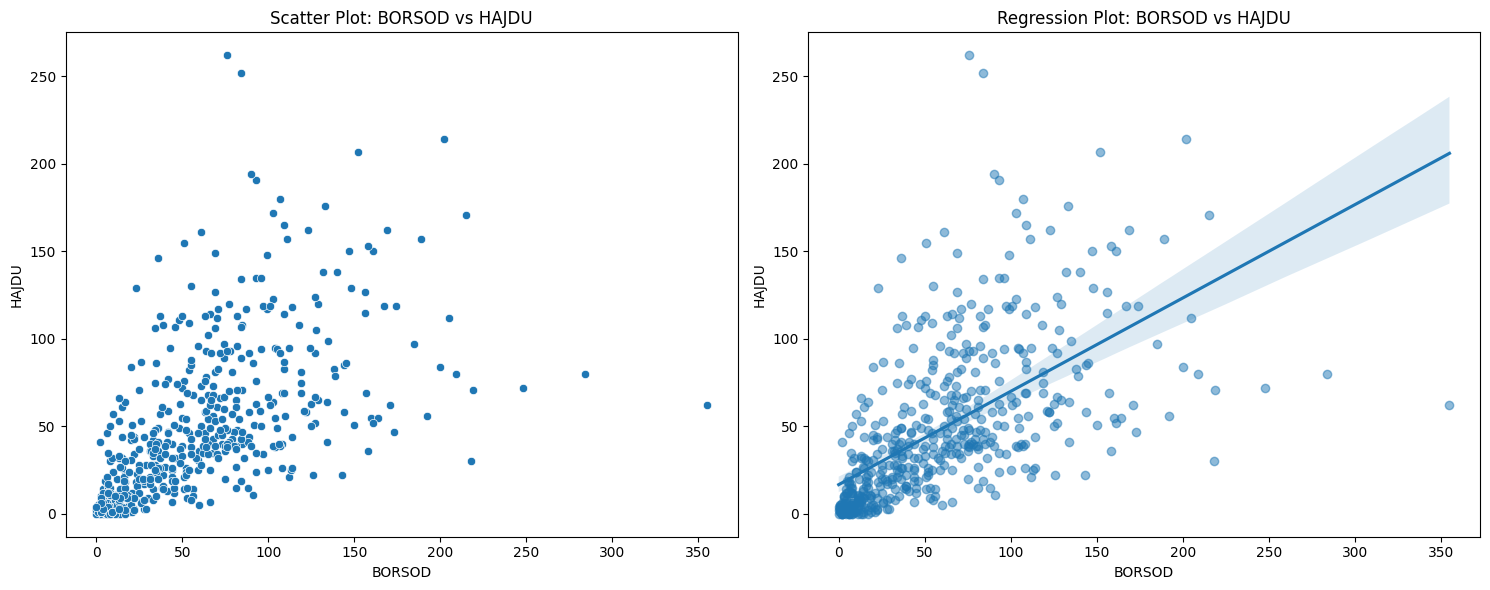


Correlation between BORSOD and HAJDU: 0.6064
This indicates a moderate positive relationship.


<Figure size 1500x600 with 0 Axes>

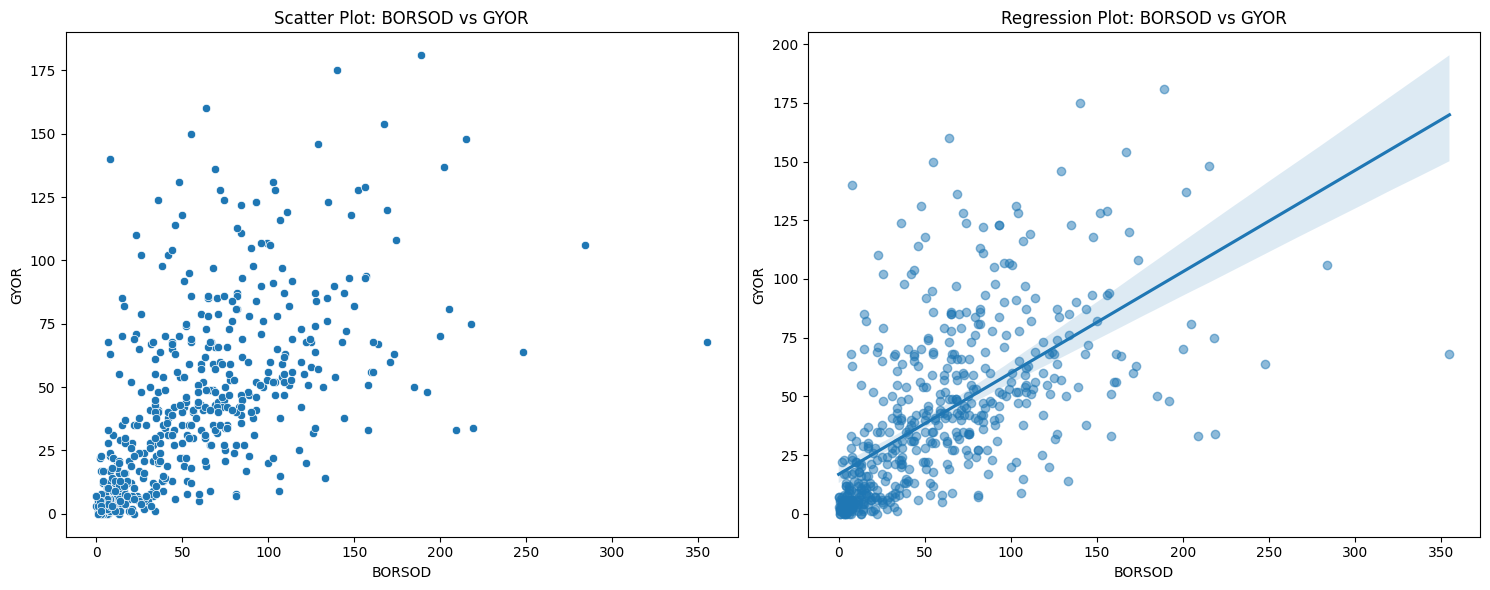


Correlation between BORSOD and GYOR: 0.6074
This indicates a moderate positive relationship.


<Figure size 1500x600 with 0 Axes>

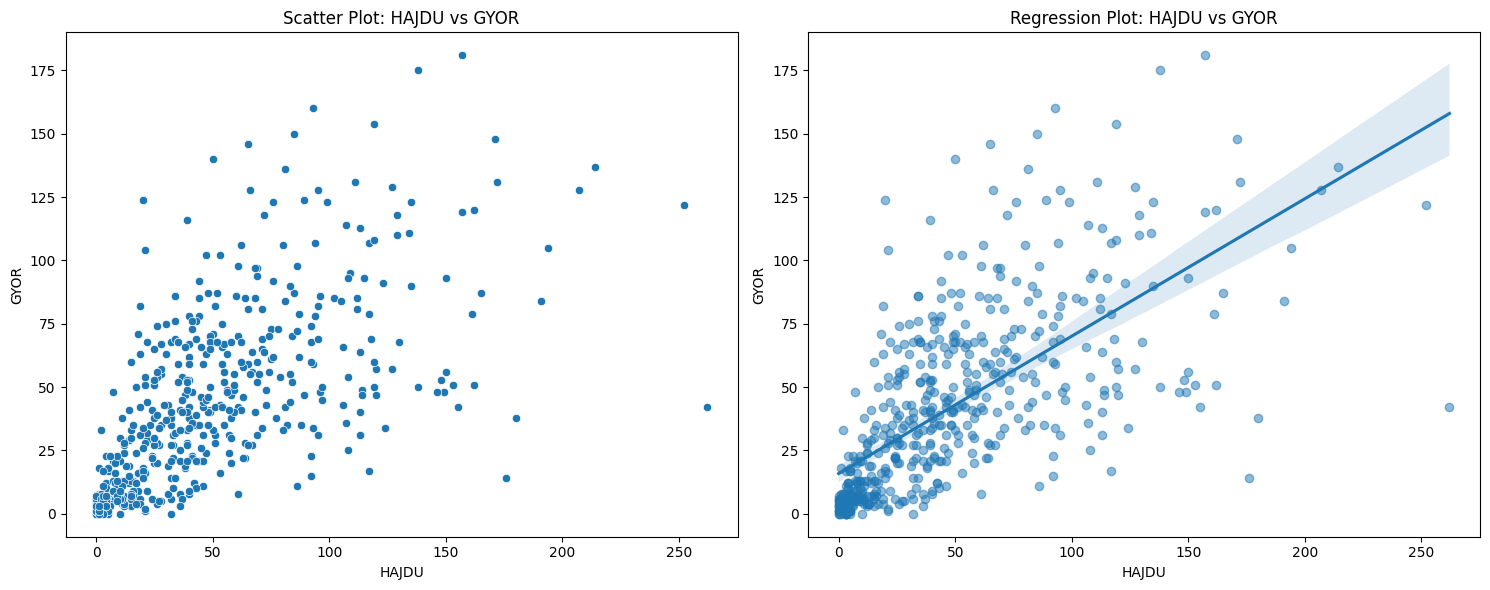


Correlation between HAJDU and GYOR: 0.6719
This indicates a moderate positive relationship.


<Figure size 1500x600 with 0 Axes>

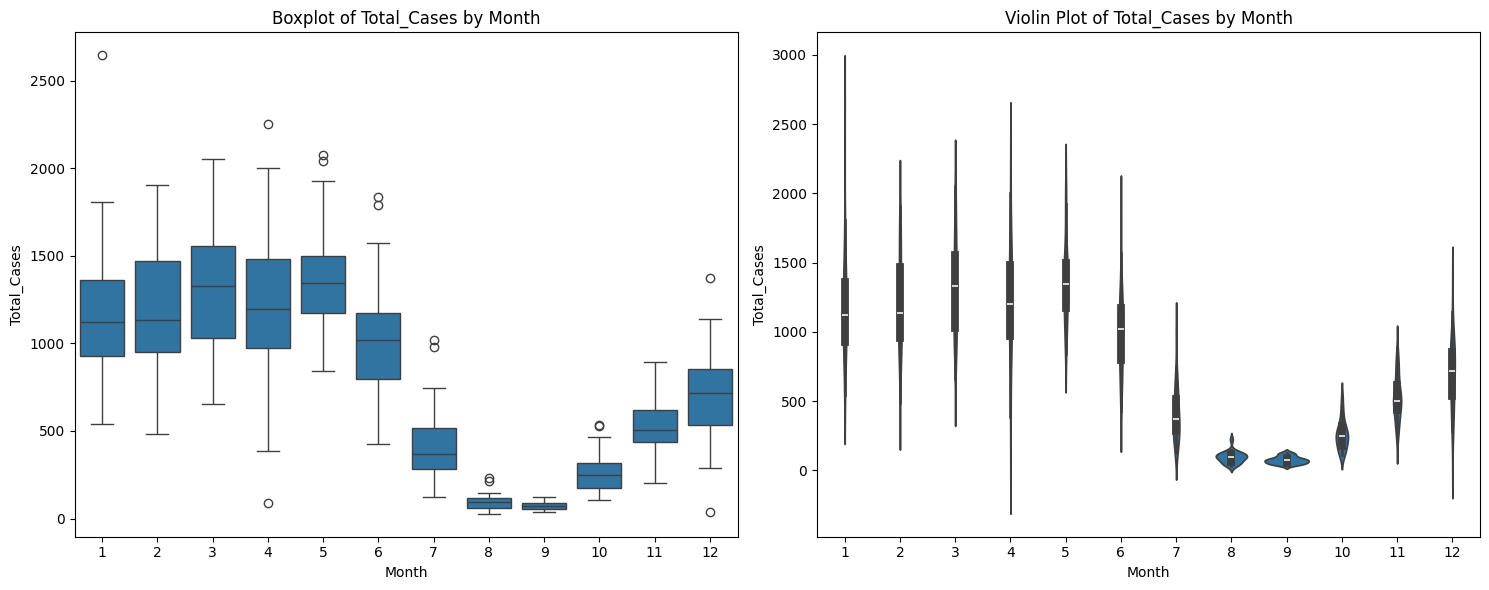


Group Statistics for Total_Cases by Month:
              mean  median         std
Month                                 
1      1175.044444  1120.0  376.947124
2      1201.350000  1133.5  348.979799
3      1319.113636  1327.5  357.736048
4      1223.511628  1198.0  427.293385
5      1362.431818  1346.0  297.301695
6      1011.000000  1022.0  312.190799
7       411.727273   368.5  205.306392
8        94.522727    95.0   42.181495
9        74.558140    71.0   26.378475
10      259.066667   250.0  106.517903
11      524.238095   503.0  160.240796
12      696.866667   719.0  256.381073

ANOVA test: F-statistic = 139.8256, p-value = 0.0000
The difference in Total_Cases across Month groups is statistically significant.


<Figure size 1500x600 with 0 Axes>

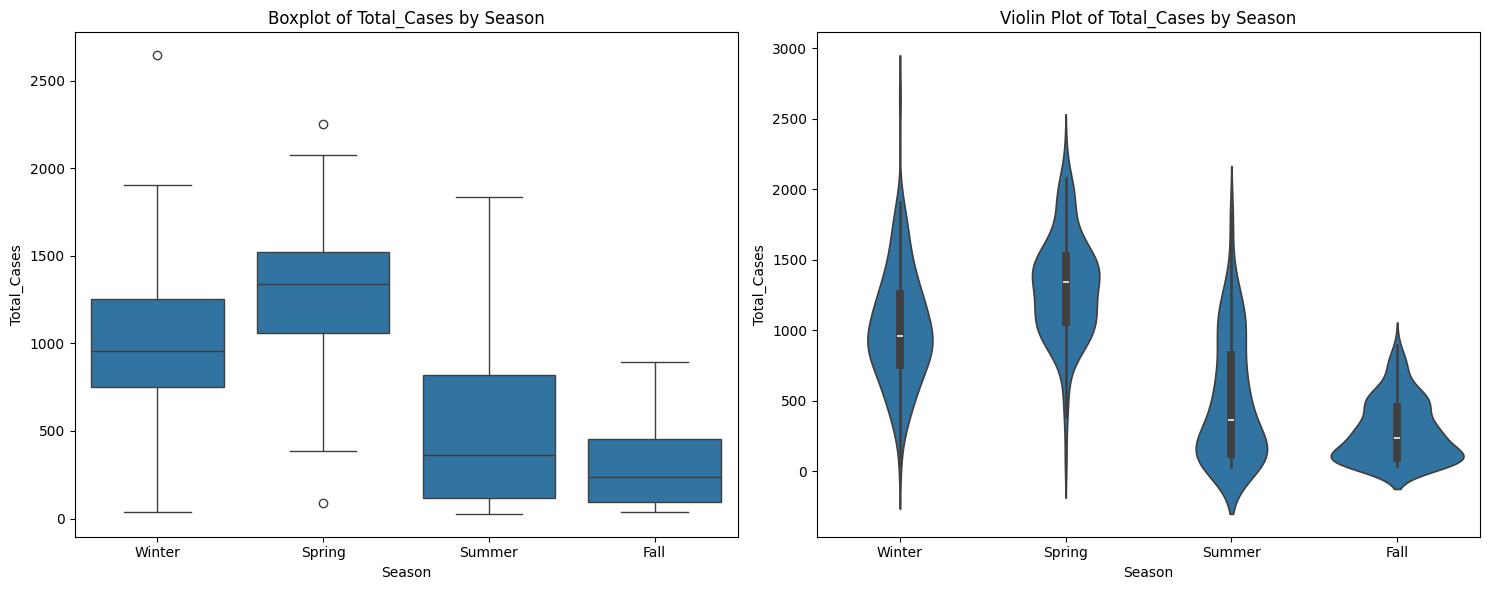


Group Statistics for Total_Cases by Season:
               mean  median         std
Season                                 
Fall     283.707692   234.5  214.212328
Spring  1302.282443  1339.0  365.959566
Summer   501.893130   360.0  436.658153
Winter  1017.615385   959.0  403.367480

ANOVA test: F-statistic = 212.9303, p-value = 0.0000
The difference in Total_Cases across Season groups is statistically significant.


<Figure size 1500x600 with 0 Axes>

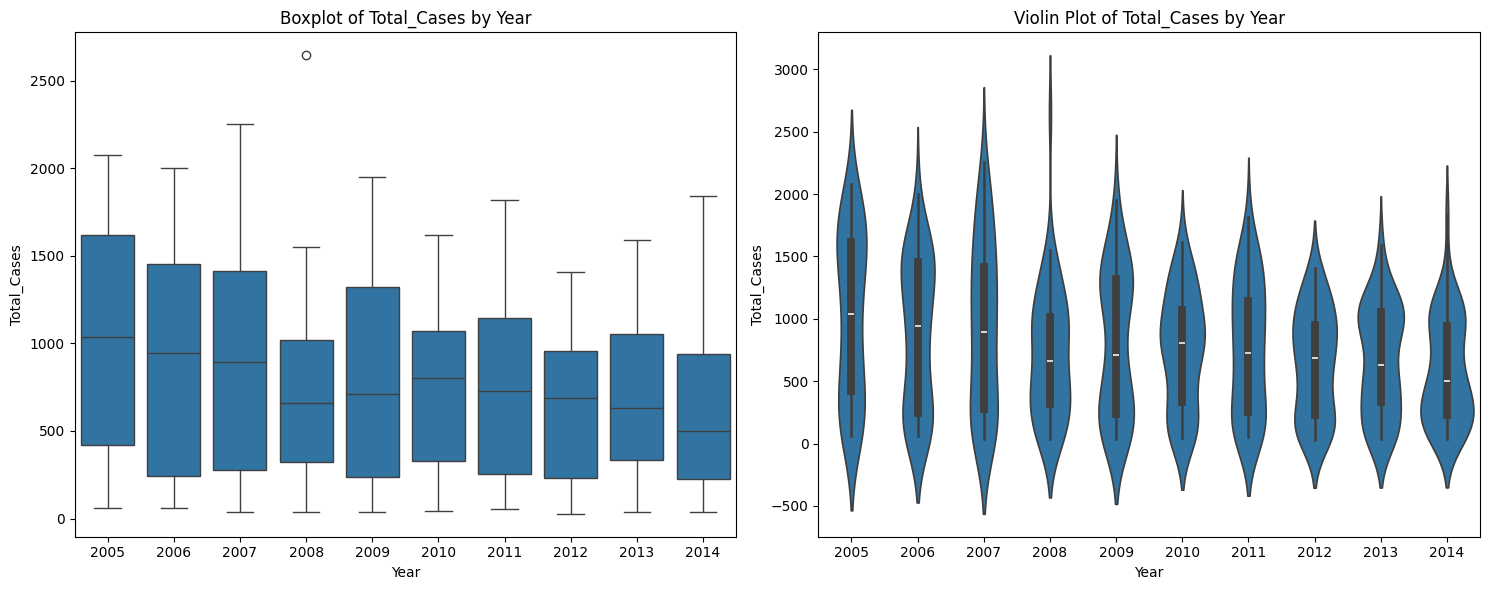


Group Statistics for Total_Cases by Year:
             mean  median         std
Year                                 
2005  1023.326923  1034.5  658.694809
2006   883.480769   945.0  588.387710
2007   935.377358   893.0  664.254360
2008   712.634615   659.0  514.771871
2009   797.153846   712.5  575.357430
2010   749.384615   803.0  453.849857
2011   770.846154   726.5  520.218445
2012   645.660377   687.0  421.961397
2013   667.230769   631.5  430.829779
2014   582.942308   499.0  427.433490

ANOVA test: F-statistic = 3.4614, p-value = 0.0004
The difference in Total_Cases across Year groups is statistically significant.


<Figure size 1500x600 with 0 Axes>

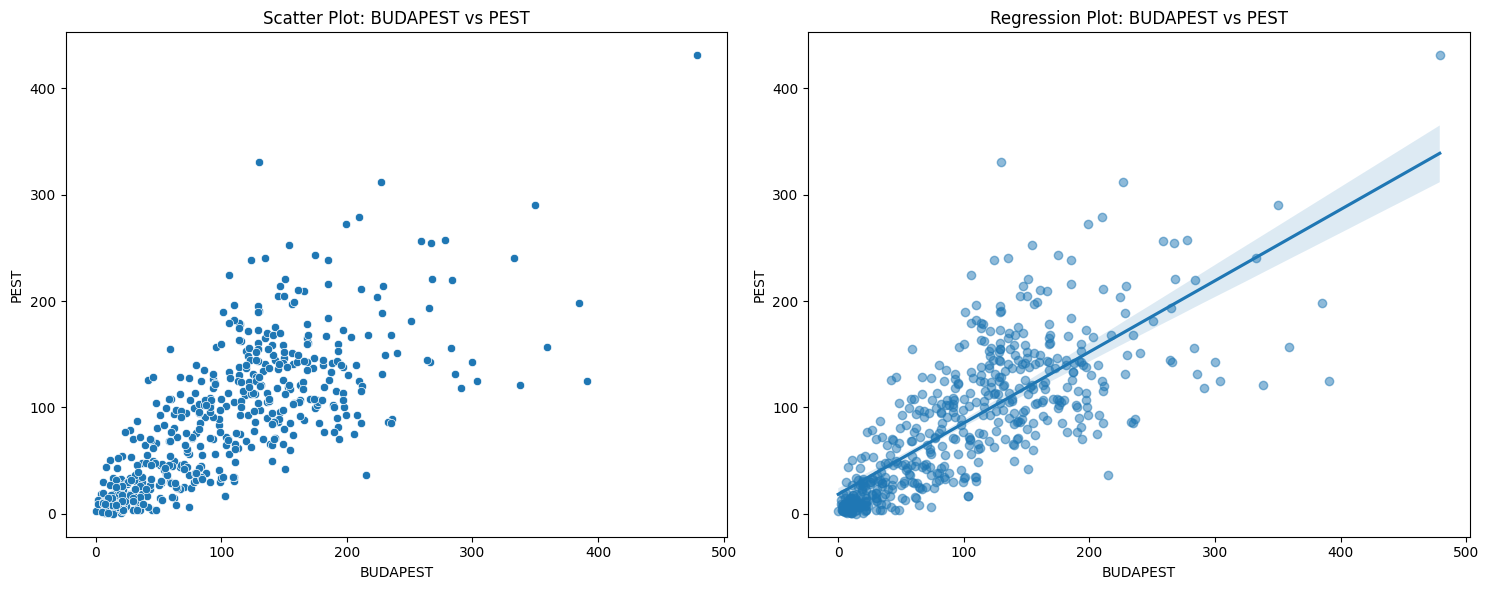


Correlation between BUDAPEST and PEST: 0.7651
This indicates a strong positive relationship.


<Figure size 1500x600 with 0 Axes>

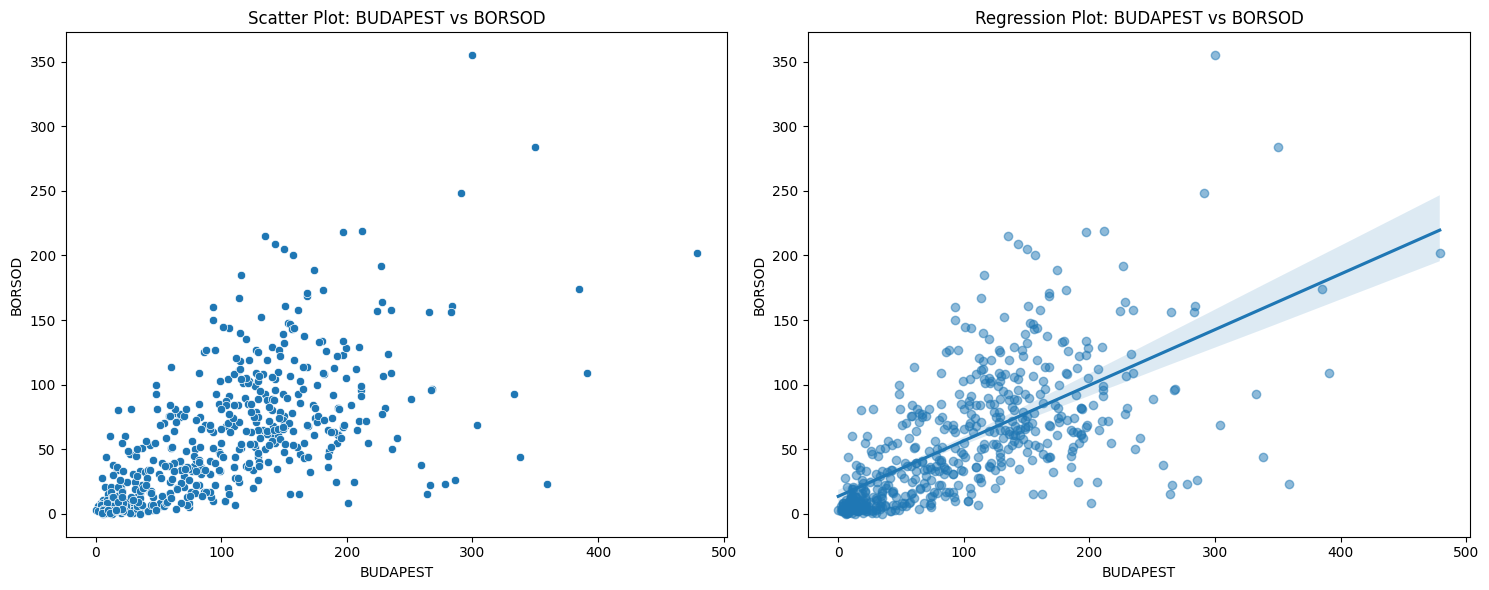


Correlation between BUDAPEST and BORSOD: 0.6476
This indicates a moderate positive relationship.


<Figure size 1500x600 with 0 Axes>

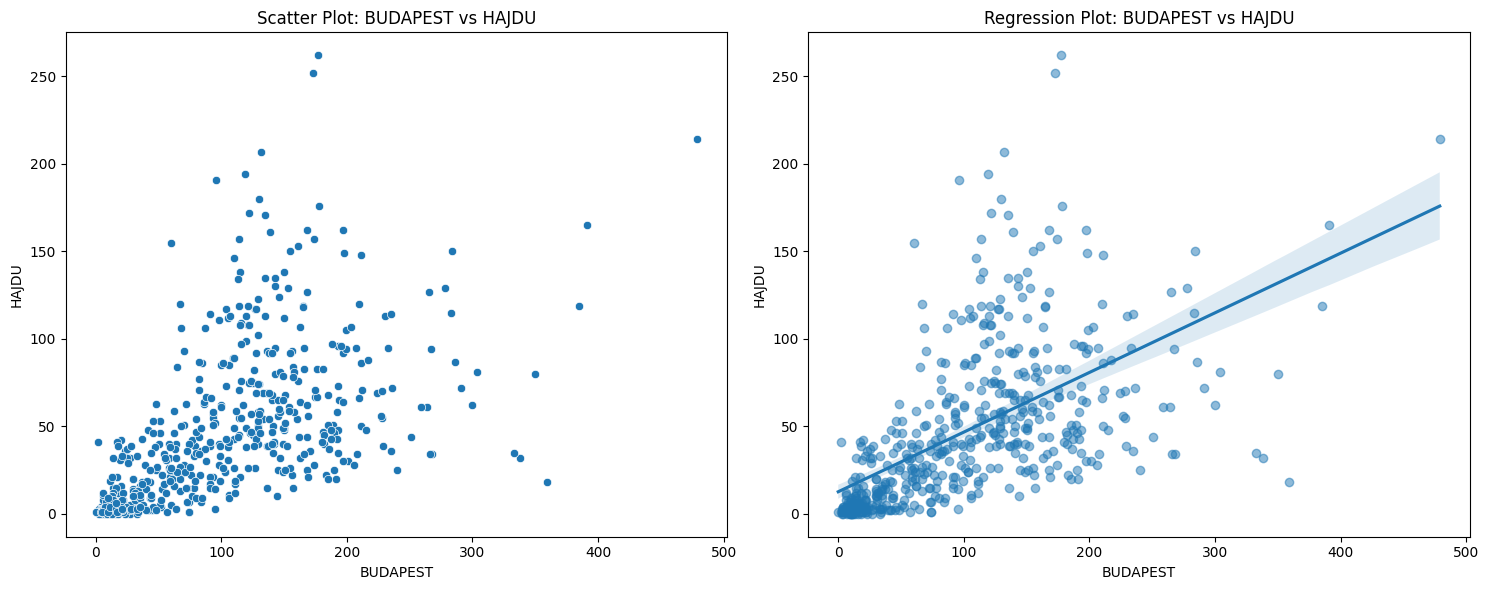


Correlation between BUDAPEST and HAJDU: 0.5832
This indicates a moderate positive relationship.


<Figure size 1500x600 with 0 Axes>

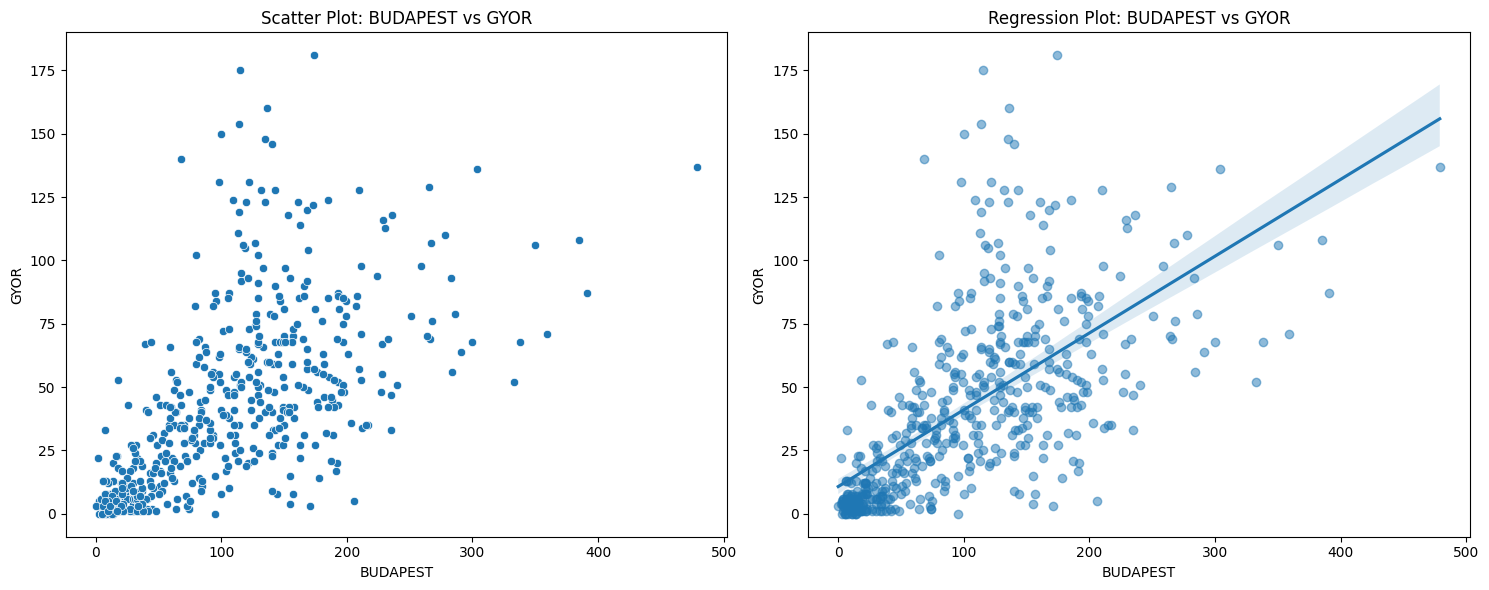


Correlation between BUDAPEST and GYOR: 0.6426
This indicates a moderate positive relationship.


In [272]:
# Analyze relationship between top counties
for i, county1 in enumerate(top_counties):
    for county2 in top_counties[i+1:]:
        bivariate_analysis(cases_df_bk, county1, county2)

# Analyze seasonal effects
bivariate_analysis(cases_df_bk, 'Total_Cases', 'Month')
bivariate_analysis(cases_df_bk, 'Total_Cases', 'Season')
bivariate_analysis(cases_df_bk, 'Total_Cases', 'Year')

# Analyze Budapest vs other counties
for county in top_counties[1:]:  # Skip Budapest itself
    bivariate_analysis(cases_df_bk, 'BUDAPEST', county)


Text(0, 0.5, 'Average Cases')

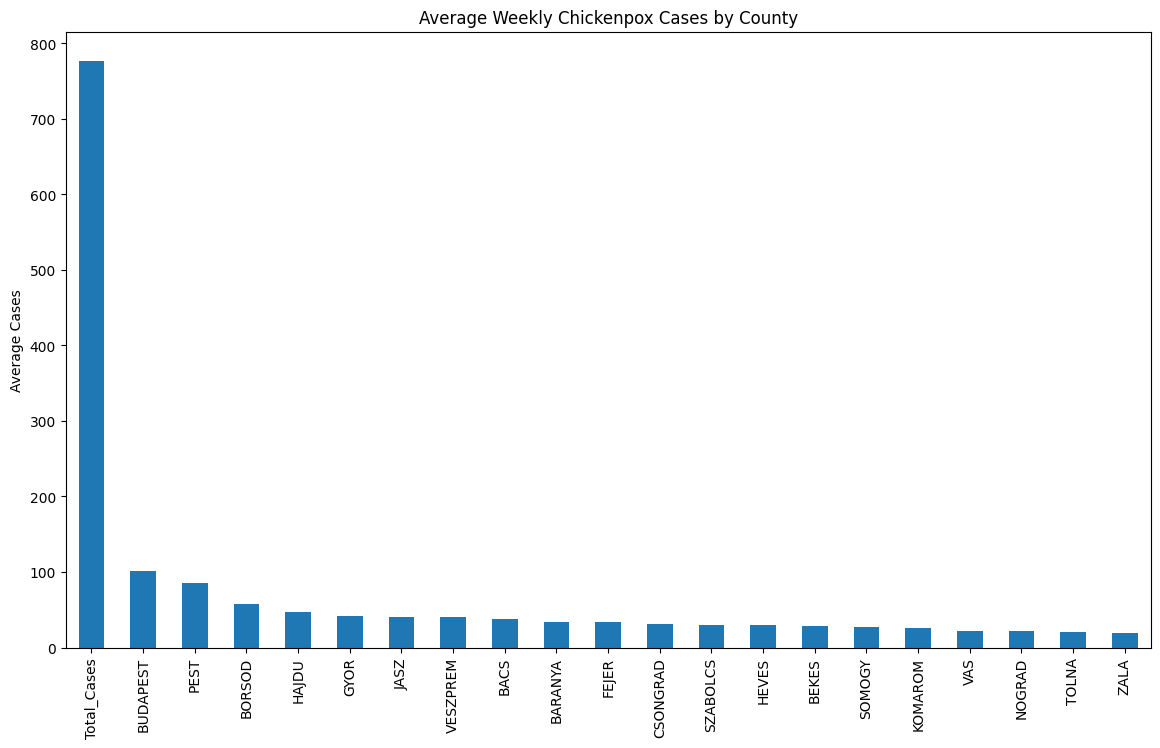

In [274]:
# Calculate average cases by county
avg_cases = cases_df_bk[counties].mean().sort_values(ascending=False)

# Plot average cases by county
plt.figure(figsize=(14, 8))
avg_cases.plot(kind='bar')
plt.title('Average Weekly Chickenpox Cases by County')
plt.ylabel('Average Cases')


conclusion:

The SARIMA(Seasonal Autoregressive Integrated Moving Average) model captures the periodic nature of chickenpox outbreaks, closely mimicking the real case occurrences in the test data.

The model does a better job of predicting general trends rather than precise weekly case numbers, as seen by the smoothed forecast curve and the high number of peaks and troughs of the test data which are not closely followed by the model's predictions. These inaccuracies reflect characteristics such spatio-temporal factors like seasonality, outbreaks, and heteroskedasticity.


 However, The SARIMA model's good performance within the confidence intervals (shaded region) for a major part of the forecast period suggests a robust capacity to predict future trends and provides useful insight for targeted treatments.